# Customer Churn — Consolidated EDA

End-to-end exploratory data analysis of the `customer_churn` data warehouse.

**Sections**
1. Setup & Data Loading
2. Churn Distribution
3. Numerical Feature Distributions (KDE · Histogram · Box · Violin)
4. Categorical & Binary Feature Distributions
5. Focused Churn Analysis
   - 5a. Services Breakdown (Churned vs Retained)
   - 5b. Total Charges by Churn Status
   - 5c. Customer Satisfaction vs Churn
   - 5d. Complaints vs Churn
   - 5e. Income Group vs Churn
   - 5f. Age Group vs Churn
   - 5g. Contract Type vs Churn
   - 5h. Monthly Charges vs Churn
   - 5i. Tenure vs Churn
6. Correlation Analysis
   - 6a. Numeric — Pearson Correlation
   - 6b. Categorical — Cramér's V
   - 6c. Mixed — All Features Encoded
7. Per-Dimension Feature Relevance (Statistical Association + Mutual Information)
   - 7a. Customer Dimension
   - 7b. Account Dimension
   - 7c. Service Dimension
   - 7d. Behaviour Dimension
   - 7e. Fact Dimension
8. Collinearity Investigation (Training Features)

## 1. Setup & Data Loading

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sqlalchemy import create_engine

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [8]:
# Database connection
USER, PASSWORD, HOST, DB = 'bt4301', 'password', 'localhost', 'customer_churn'
engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}')

In [9]:
# Main dataset — joins all dimension tables onto the fact table
query = """
SELECT
    f.customer_id,
    f.churn,
    f.monthlycharges,
    f.totalcharges,
    f.avg_charge_per_month,
    c.age,
    c.gender,
    c.annual_income,
    c.education,
    c.marital_status,
    c.dependents,
    c.senior_citizen,
    c.tenure_segment,
    a.tenure,
    a.contract,
    a.payment_method,
    a.paperless_billing,
    s.num_services,
    s.has_phone_service,
    s.has_internet_service,
    s.has_online_security,
    s.has_online_backup,
    s.has_device_protection,
    s.has_tech_support,
    s.has_streaming_tv,
    s.has_streaming_movies,
    b.customer_satisfaction,
    b.num_complaints,
    b.num_service_calls,
    b.late_payments,
    b.avg_monthly_gb,
    b.days_since_last_interaction,
    b.credit_score,
    b.high_risk_flag
FROM fact_customer_churn f
LEFT JOIN dim_customer  c ON f.customer_id = c.customer_id
LEFT JOIN dim_account   a ON f.customer_id = a.customer_id
LEFT JOIN dim_service   s ON f.customer_id = s.customer_id
LEFT JOIN dim_behavior  b ON f.customer_id = b.customer_id
"""

df = pd.read_sql(query, engine)
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head()

Rows: 1,000,000  |  Columns: 34


,customer_id,churn,monthlycharges,totalcharges,avg_charge_per_month,age,gender,annual_income,education,marital_status,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,high_risk_flag
0,CUST0000000047,0,115.93,5894.70,109.161111,47,Female,30347.14,college,single,...,1,0,8.0,0.0,0,0,36.13,5,804.0,0
1,CUST0000000091,0,128.81,6431.69,133.993542,45,Male,48894.76,master,married,...,0,0,7.0,0.0,0,0,40.42,92,550.0,1
2,CUST0000000140,0,65.82,1391.53,66.263333,56,Female,71159.08,bachelor,married,...,0,1,6.0,1.0,2,0,0.00,19,758.0,0
3,CUST0000000202,0,56.14,3541.49,59.024833,32,Male,20000.00,high_school,divorced,...,1,0,5.0,0.0,1,1,13.80,41,676.0,0
4,CUST0000000214,0,59.11,64.09,64.090000,41,Female,34528.27,bachelor,married,...,1,0,8.0,0.0,2,1,15.74,8,634.0,0


In [10]:
# Training table (used in collinearity section)
df_train = pd.read_sql('SELECT * FROM train_churn_model', engine)
print(f'Train rows: {len(df_train):,}  |  Columns: {df_train.shape[1]}')
df_train.head()

Train rows: 1,000,000  |  Columns: 17


,customer_id,churn,annual_income,contract,has_phone_service,has_internet_service,has_tech_support,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,high_risk_flag,age_group,tenure_segment,is_auto_pay
0,CUST0000000047,0,30347.14,one_year,1,1,1,1,0,8.0,0.0,0,0,0,40-49,Loyal,1
1,CUST0000000091,0,48894.76,one_year,0,1,1,0,0,7.0,0.0,0,0,1,40-49,Loyal,1
2,CUST0000000140,0,71159.08,two_year,1,0,0,0,1,6.0,1.0,2,0,0,50-59,Stable,1
3,CUST0000000202,0,20000.00,one_year,1,1,1,1,0,5.0,0.0,1,1,0,30-39,Loyal,1
4,CUST0000000214,0,34528.27,two_year,1,1,1,1,0,8.0,0.0,2,1,0,40-49,Infant,1


In [11]:
# --- Column groups (used throughout the notebook) ---
NUM_COLS = [
    'age', 'annual_income', 'dependents', 'tenure',
    'num_services', 'customer_satisfaction', 'num_complaints',
    'num_service_calls', 'late_payments', 'avg_monthly_gb',
    'days_since_last_interaction', 'credit_score',
    'monthlycharges', 'totalcharges', 'avg_charge_per_month',
]

CAT_COLS = [
    'gender', 'education', 'marital_status', 'paperless_billing',
    'contract', 'payment_method',
]

BINARY_COLS = [
    'senior_citizen', 'has_phone_service', 'has_internet_service',
    'has_online_security', 'has_online_backup', 'has_device_protection',
    'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
    'high_risk_flag',
]

SERVICE_COLS = [c for c in df.columns if c.startswith('has_')]

# Convenience splits
df_churned   = df[df['churn'] == 1]
df_retained  = df[df['churn'] == 0]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 34 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  object 
 1   churn                        1000000 non-null  int64  
 2   monthlycharges               1000000 non-null  float64
 3   totalcharges                 1000000 non-null  float64
 4   avg_charge_per_month         1000000 non-null  float64
 5   age                          1000000 non-null  int64  
 6   gender                       1000000 non-null  object 
 7   annual_income                1000000 non-null  float64
 8   education                    1000000 non-null  object 
 9   marital_status               1000000 non-null  object 
 10  dependents                   1000000 non-null  int64  
 11  senior_citizen               1000000 non-null  int64  
 12  tenure_segment               1000000 non-nu

## 2. Churn Distribution

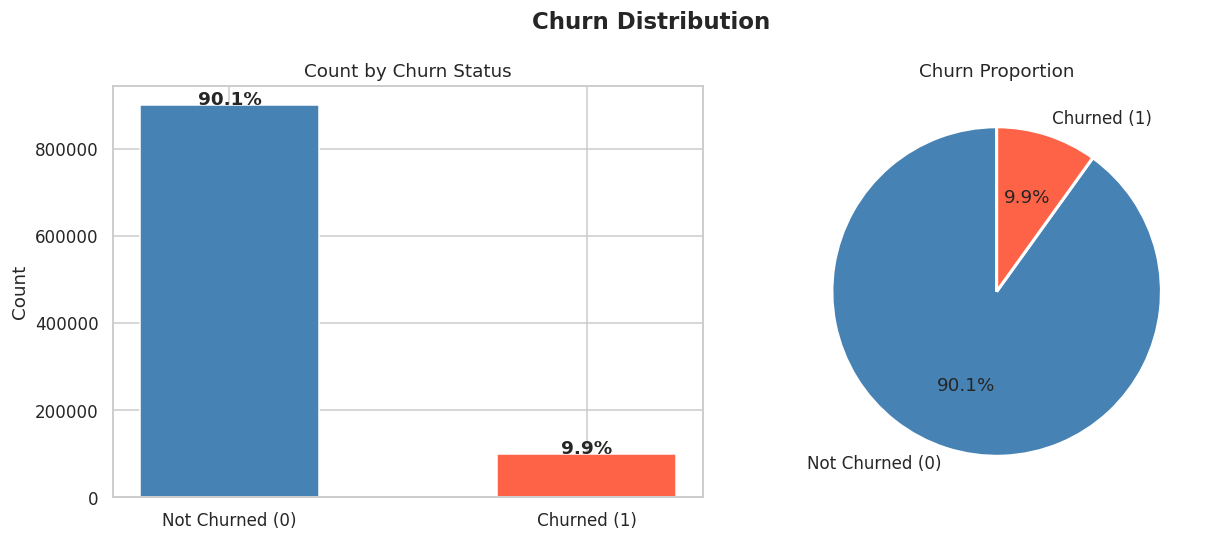

              Count      Pct
churn                       
Not Churned  900773  90.0773
Churned       99227   9.9227


In [12]:
churn_counts = df['churn'].value_counts()
churn_labels = ['Not Churned (0)', 'Churned (1)']
churn_pct    = churn_counts / churn_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=15, fontweight='bold')

bars = axes[0].bar(churn_labels, churn_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f'{pct:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Count by Churn Status')

axes[1].pie(
    churn_counts.values, labels=churn_labels, autopct='%1.1f%%',
    colors=['steelblue', 'tomato'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print(churn_counts.rename(index={0: 'Not Churned', 1: 'Churned'})
                  .to_frame('Count')
                  .assign(Pct=churn_pct.values))

## 3. Numerical Feature Distributions
### 3a. KDE by churn status

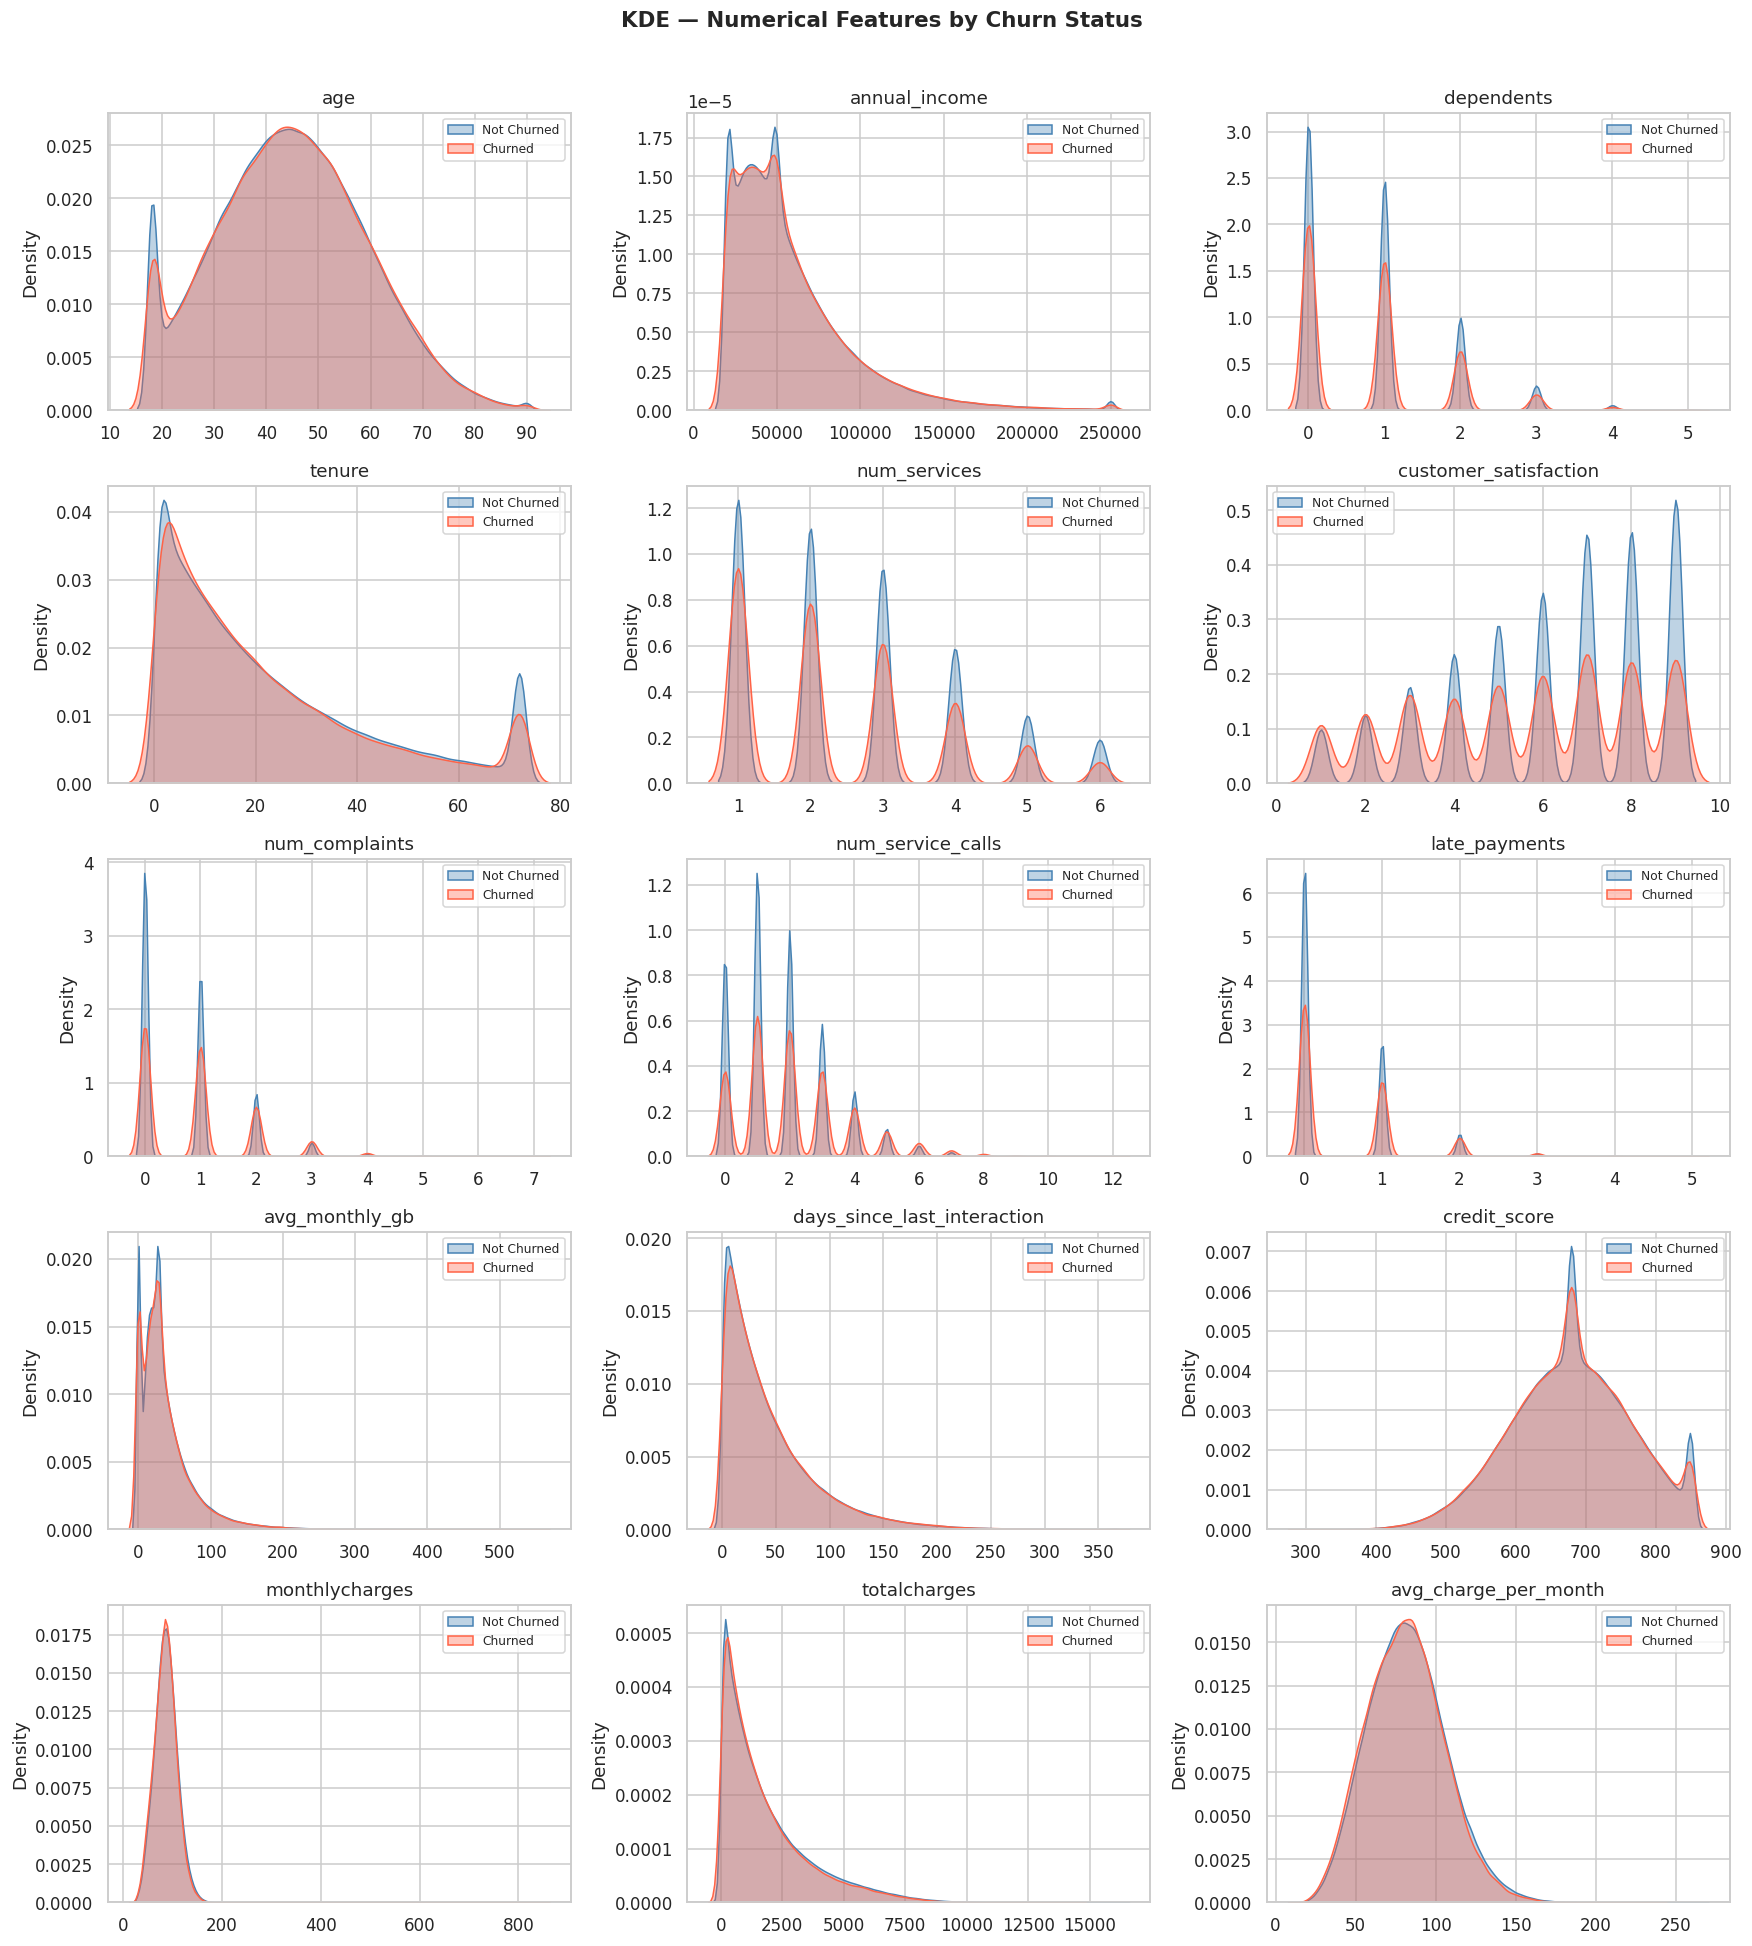

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('KDE — Numerical Features by Churn Status', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    for churn_val, color, label in [(0, 'steelblue', 'Not Churned'), (1, 'tomato', 'Churned')]:
        sns.kdeplot(df[df['churn'] == churn_val][col].dropna(),
                    ax=axes[i], color=color, label=label, fill=True, alpha=0.35)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3b. Histograms

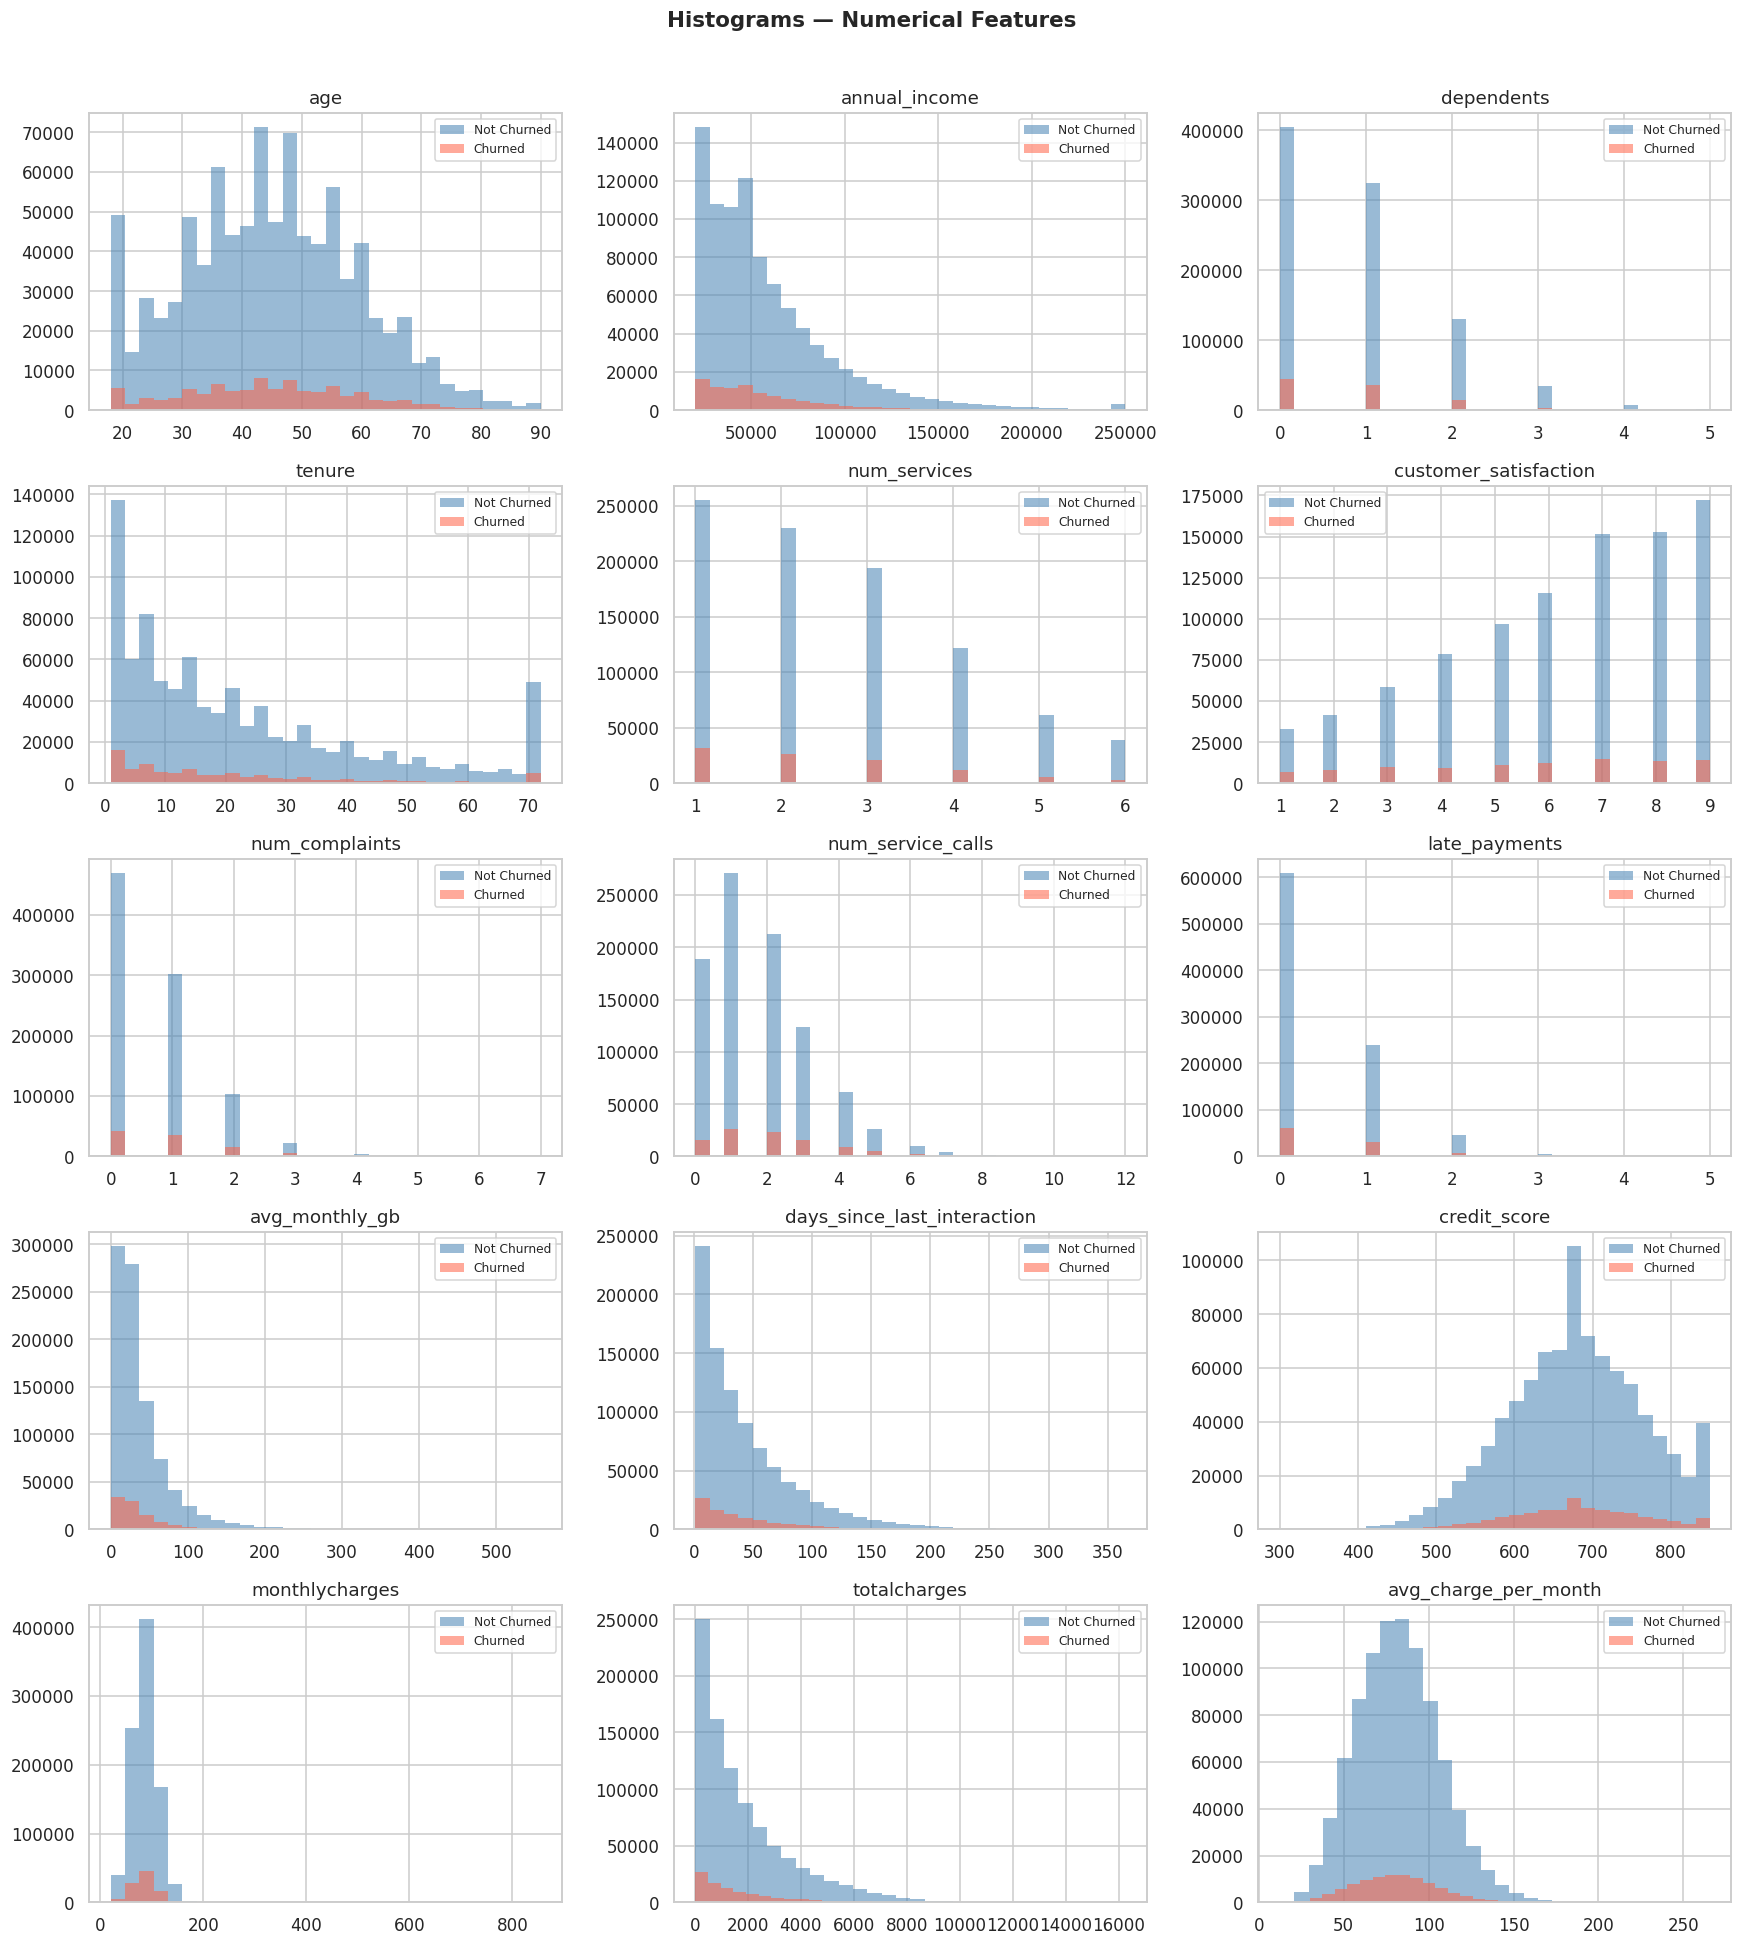

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Histograms — Numerical Features', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    for churn_val, color, label in [(0, 'steelblue', 'Not Churned'), (1, 'tomato', 'Churned')]:
        axes[i].hist(df[df['churn'] == churn_val][col].dropna(),
                     bins=30, color=color, label=label, alpha=0.55, edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3c. Box plots

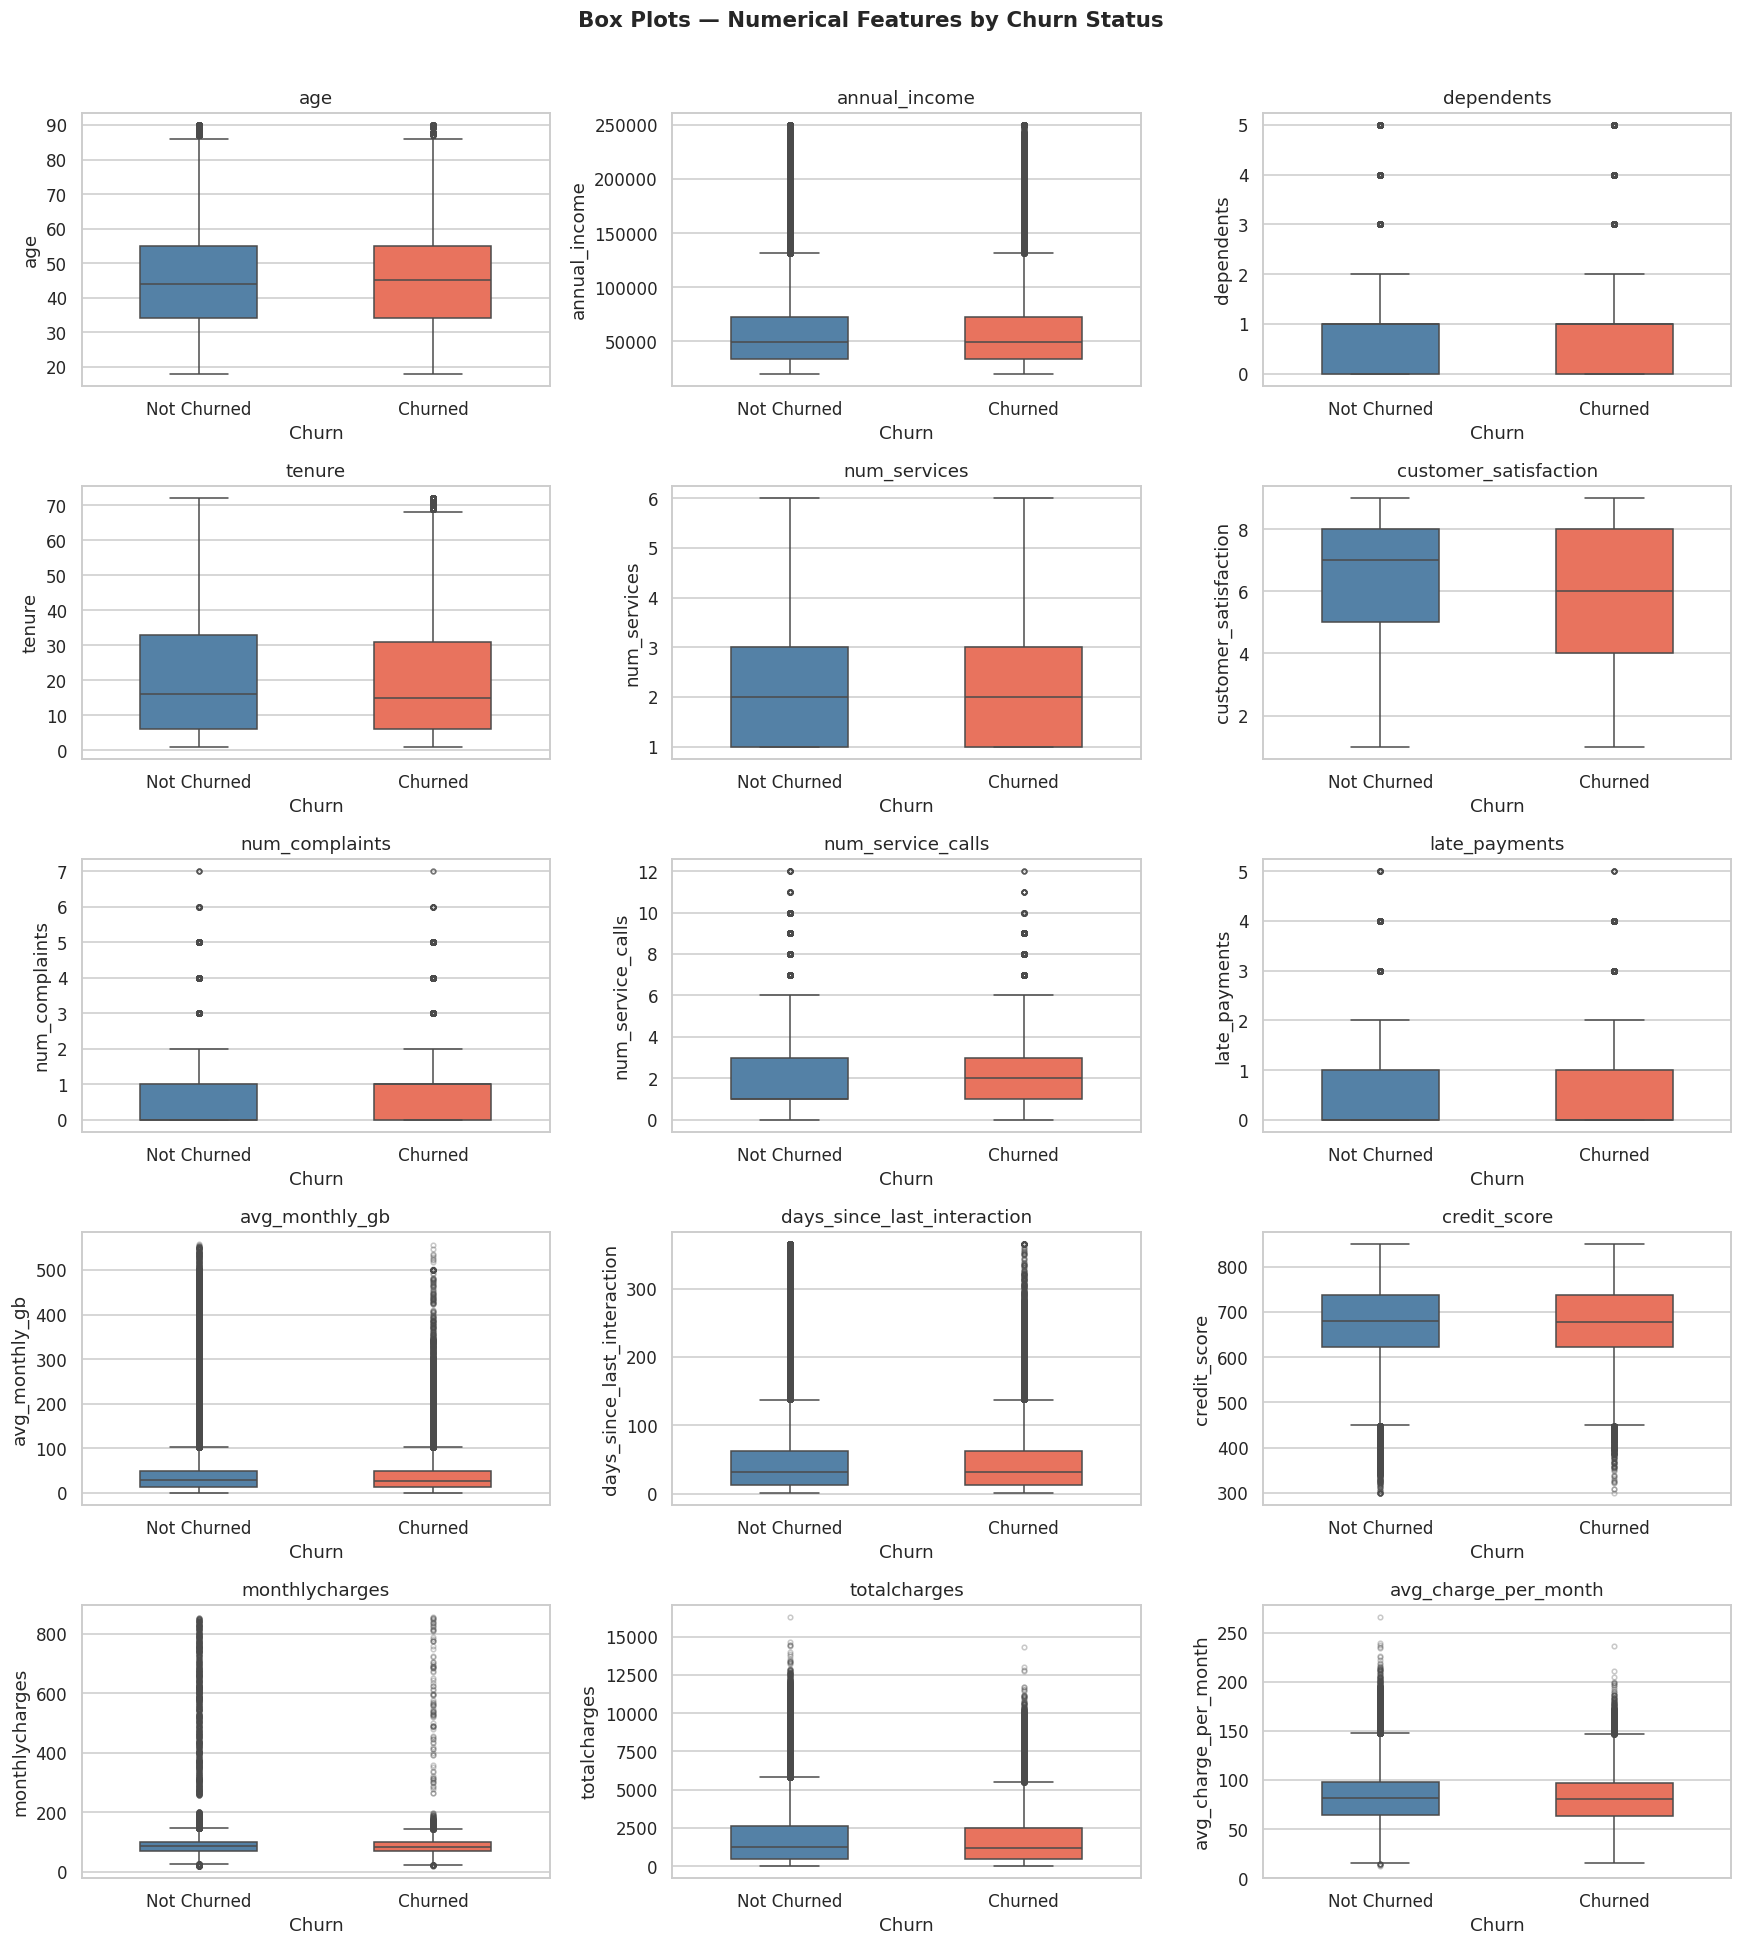

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Box Plots — Numerical Features by Churn Status', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(
        data=df, x='churn', y=col, ax=axes[i],
        palette=['steelblue', 'tomato'],
        width=0.5, flierprops={'marker': '.', 'alpha': 0.3}
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn')
    axes[i].set_xticklabels(['Not Churned', 'Churned'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3d. Violin plots

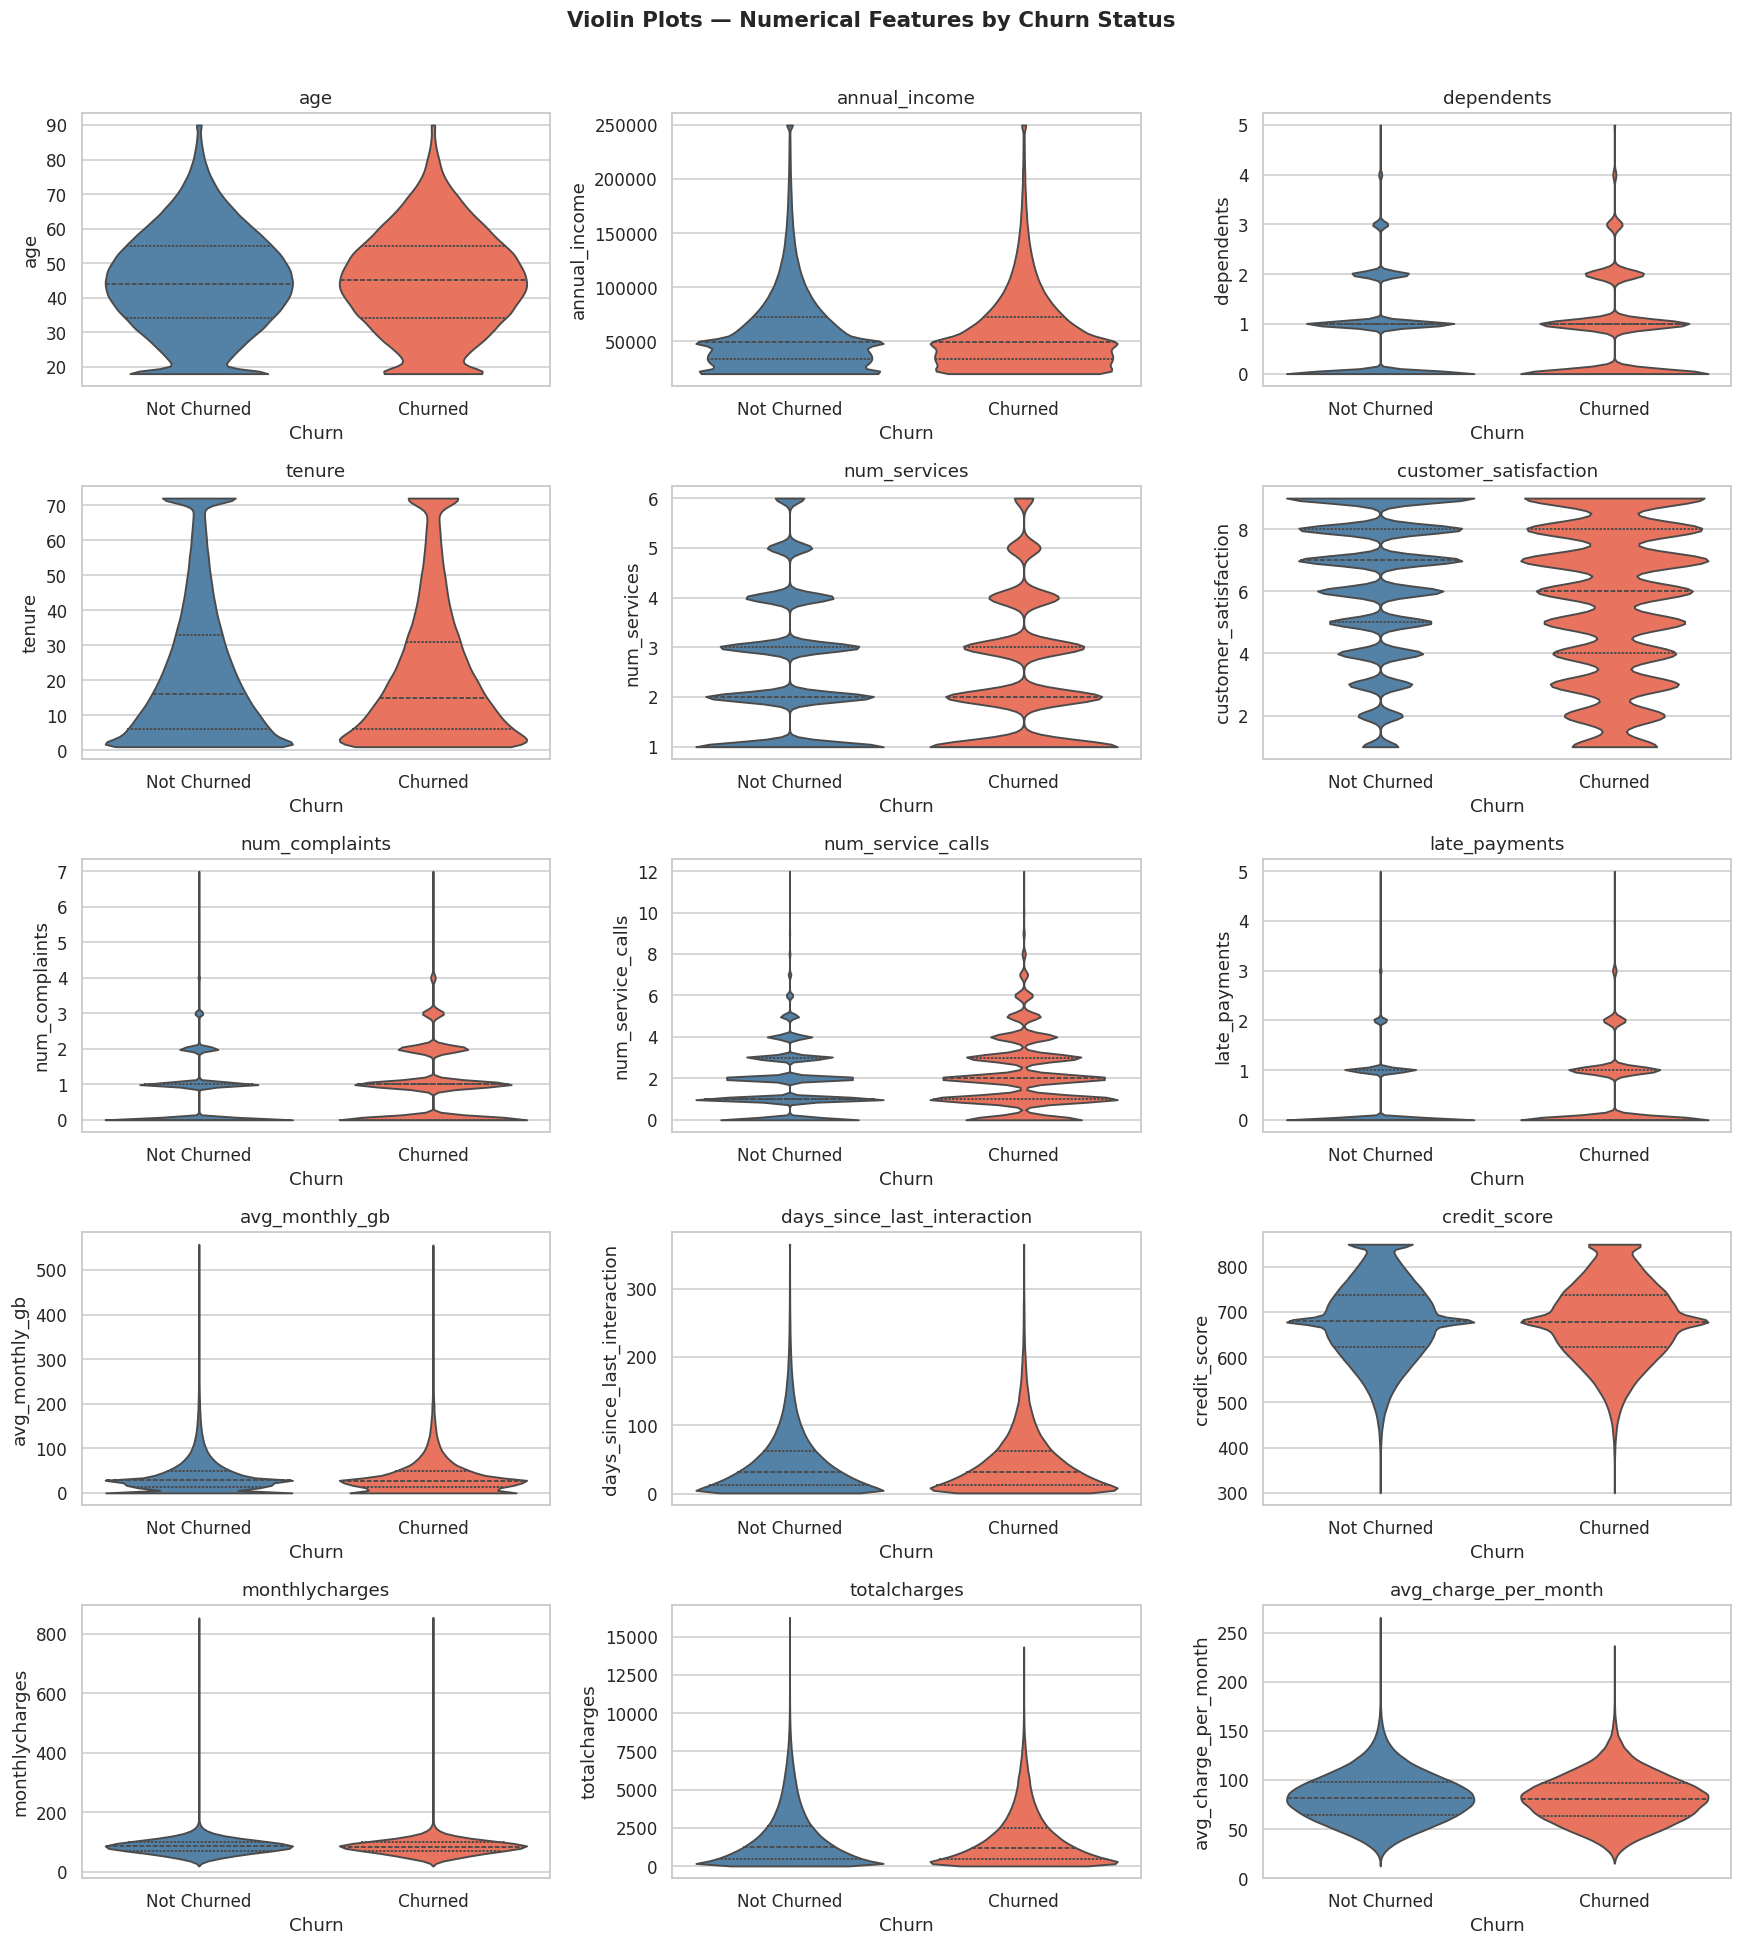

In [16]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Violin Plots — Numerical Features by Churn Status', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.violinplot(
        data=df, x='churn', y=col, ax=axes[i],
        palette=['steelblue', 'tomato'],
        inner='quartile', cut=0
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn')
    axes[i].set_xticklabels(['Not Churned', 'Churned'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Categorical & Binary Feature Distributions
### 4a. Multi-category columns

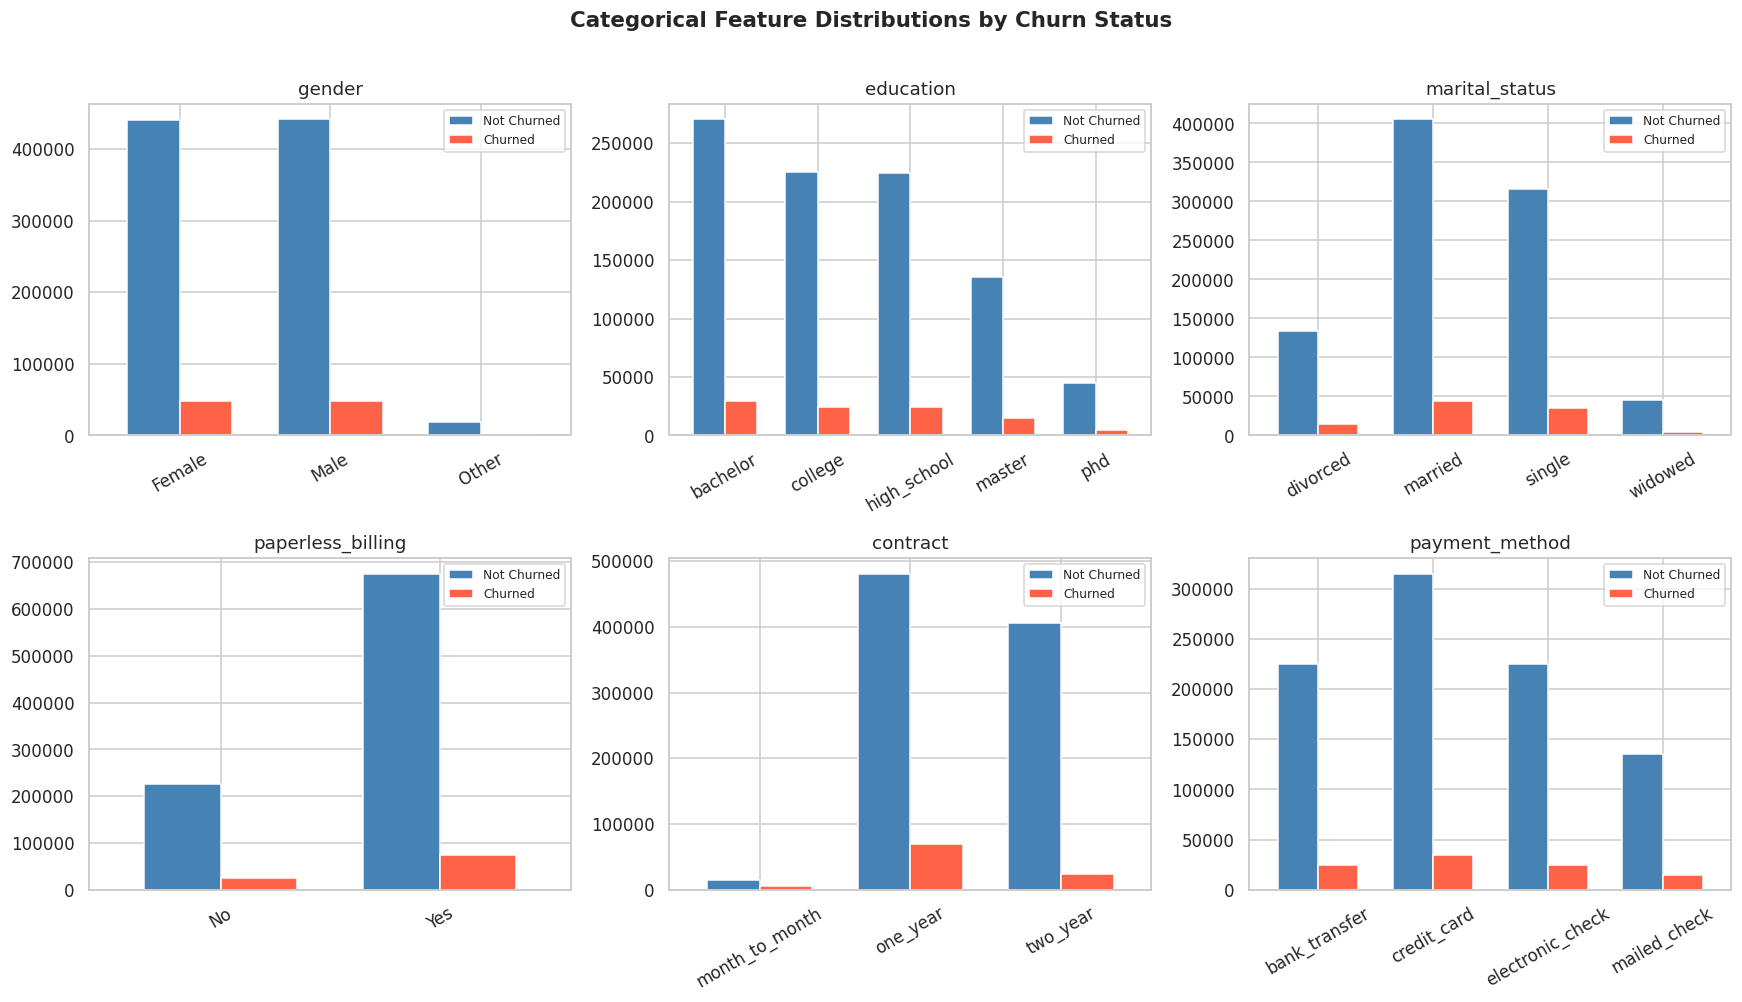

In [17]:
n_cat_rows = int(np.ceil(len(CAT_COLS) / 3))
fig, axes = plt.subplots(n_cat_rows, 3, figsize=(16, n_cat_rows * 4.5))
fig.suptitle('Categorical Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ct = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct.columns = ['Not Churned', 'Churned']
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', width=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4b. Binary / flag columns

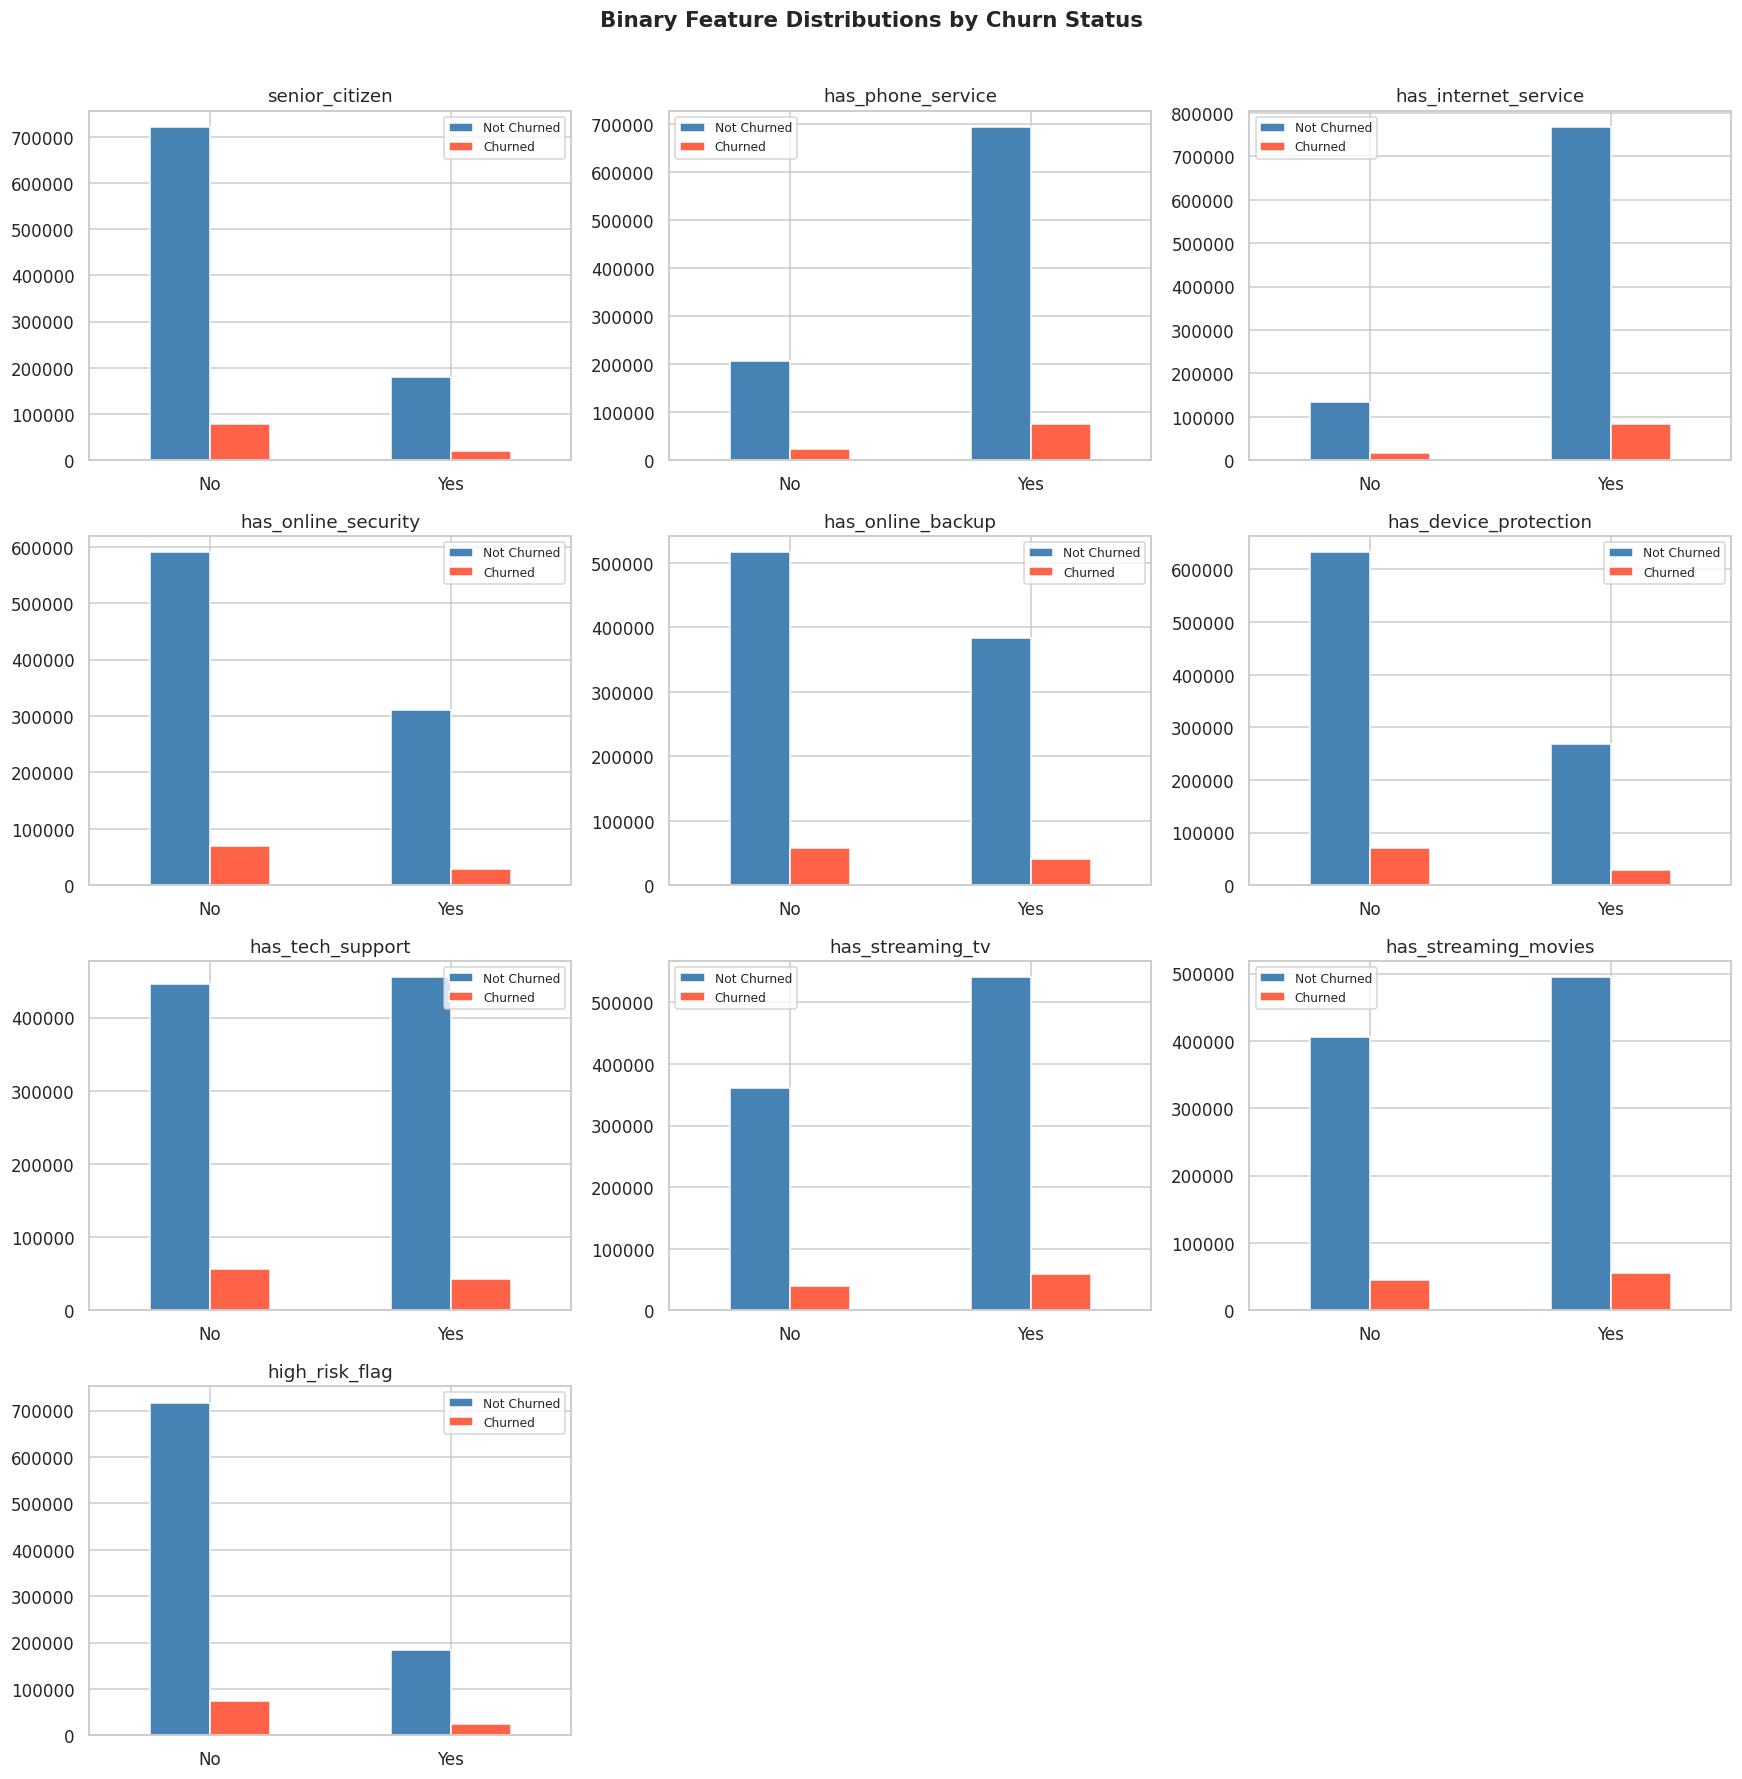

In [18]:
n_bin_rows = int(np.ceil(len(BINARY_COLS) / 3))
fig, axes = plt.subplots(n_bin_rows, 3, figsize=(16, n_bin_rows * 4))
fig.suptitle('Binary Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(BINARY_COLS):
    ct = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct.columns = ['Not Churned', 'Churned']
    ct.index = ct.index.map({0: 'No', 1: 'Yes'})
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', width=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Focused Churn Analysis
### 5a. Services Breakdown — Churned vs Retained

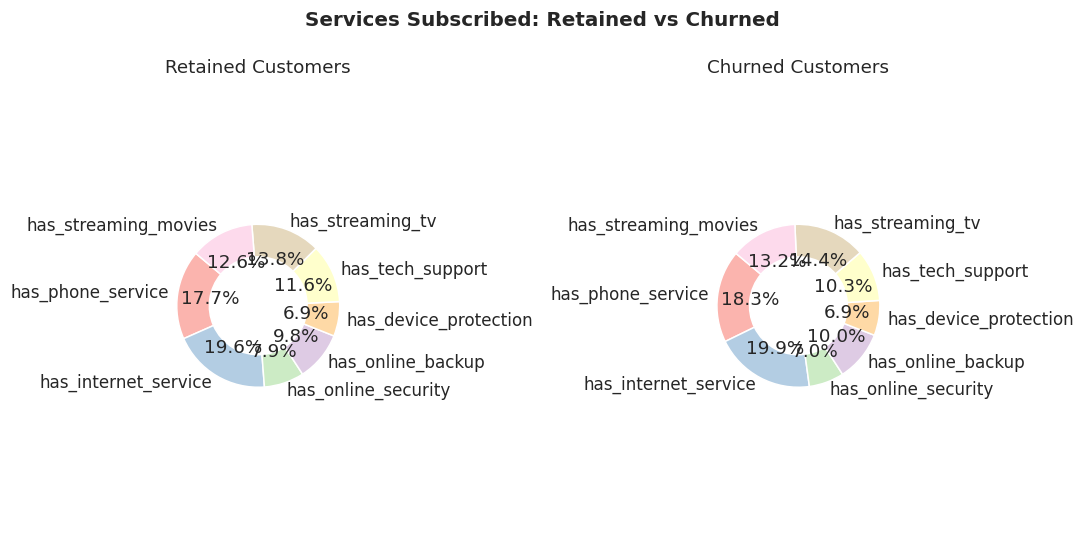

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Services Subscribed: Retained vs Churned', fontsize=13, fontweight='bold')

for ax, subset, title in [
    (axes[0], df_retained, 'Retained Customers'),
    (axes[1], df_churned,  'Churned Customers'),
]:
    svc_totals = subset[SERVICE_COLS].apply(pd.to_numeric, errors='coerce').sum()
    colors = plt.cm.Pastel1.colors[:len(svc_totals)]
    ax.pie(svc_totals.values, labels=svc_totals.index, colors=colors,
           autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.4})
    ax.set_title(title)
    ax.axis('equal')

plt.tight_layout()
plt.show()

### 5b. Total Charges by Churn Status

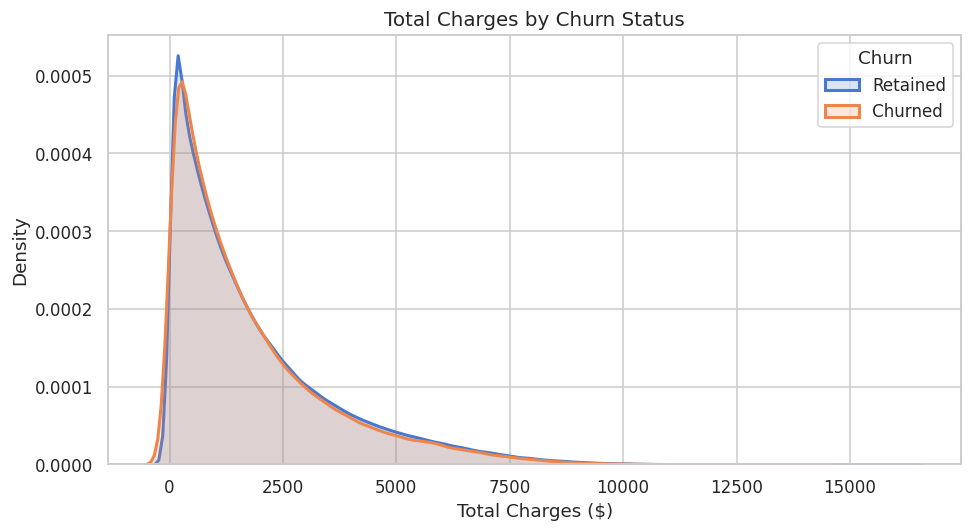

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

for churn_val, label in [(0, 'Retained'), (1, 'Churned')]:
    series = df[df['churn'] == churn_val]['totalcharges'].dropna()
    sns.kdeplot(series, ax=ax, label=label, linewidth=2, fill=True, alpha=0.2)

ax.set_title('Total Charges by Churn Status', fontsize=13)
ax.set_xlabel('Total Charges ($)')
ax.set_ylabel('Density')
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

### 5c. Customer Satisfaction vs Churn

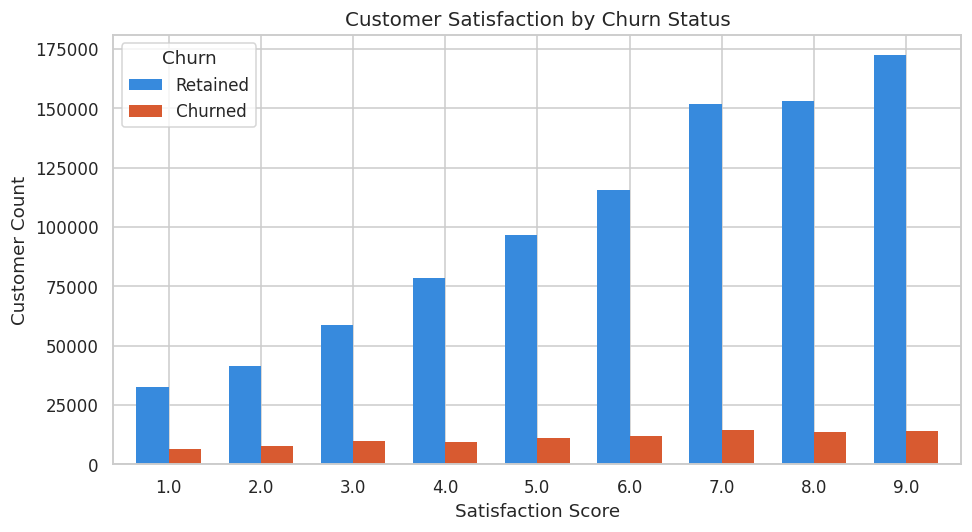

In [21]:
sat_churn = (
    df.groupby(['customer_satisfaction', 'churn'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Retained', 1: 'Churned'})
)

fig, ax = plt.subplots(figsize=(9, 5))
sat_churn.plot(kind='bar', ax=ax, color=['#378ADD', '#D85A30'],
               edgecolor='none', width=0.7)
ax.set_title('Customer Satisfaction by Churn Status', fontsize=13)
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Customer Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Churn')
plt.tight_layout()
plt.show()

### 5d. Number of Complaints vs Churn Rate

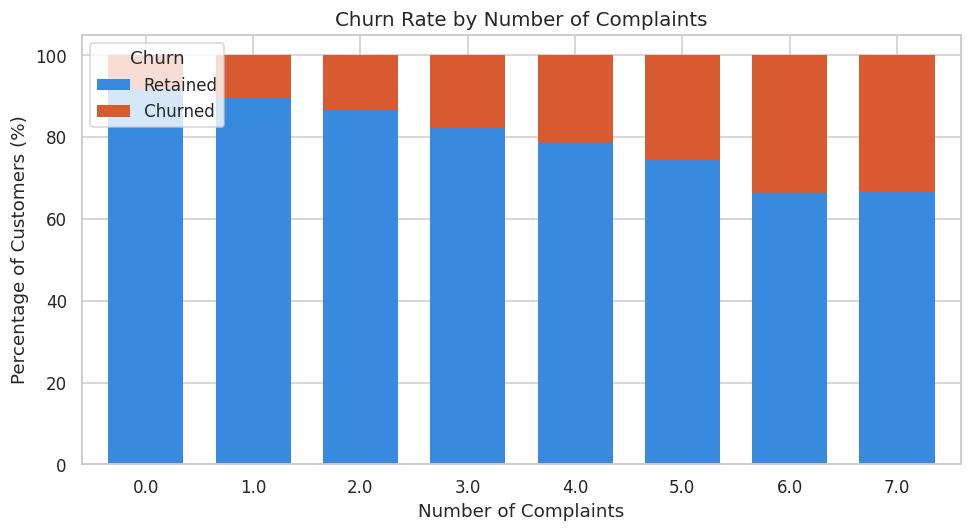

In [22]:
complaint_churn = (
    df.groupby(['num_complaints', 'churn'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Retained', 1: 'Churned'})
)
complaint_pct = complaint_churn.div(complaint_churn.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
complaint_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=['#378ADD', '#D85A30'], edgecolor='none', width=0.7)
ax.set_title('Churn Rate by Number of Complaints', fontsize=13)
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('Percentage of Customers (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Churn', loc='upper left')
plt.tight_layout()
plt.show()

### 5e. Income Group vs Churn

**Observation:** The churn rate remains broadly similar across income groups.  
**Inference:** Income group alone may not be a strong predictor of churn.

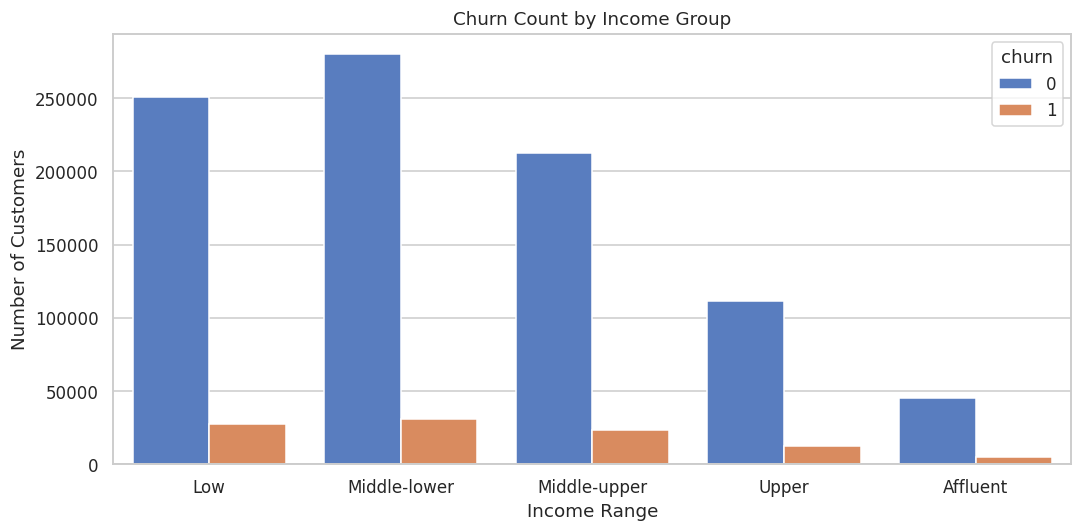

churn                 0          1
income_group                      
Low           90.063822   9.936178
Middle-lower  90.124478   9.875522
Middle-upper  90.055618   9.944382
Upper         90.099908   9.900092
Affluent      89.907894  10.092106


In [23]:
df['income_group'] = pd.cut(
    df['annual_income'],
    bins=[0, 35_000, 55_000, 85_000, 130_000, 250_000],
    labels=['Low', 'Middle-lower', 'Middle-upper', 'Upper', 'Affluent']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='income_group', hue='churn', ax=ax)
ax.set_title('Churn Count by Income Group')
ax.set_xlabel('Income Range')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

income_churn_pct = df.groupby('income_group')['churn'].value_counts(normalize=True).unstack() * 100
print(income_churn_pct)

### 5f. Age Group vs Churn

**Observation:** The 40–49 group has the highest churn volume; the youngest (18–29) and oldest (70+) groups have the least.  
**Inference:** Churn has a non-linear relationship with age — binning age into lifecycle groups is more informative than using raw age.

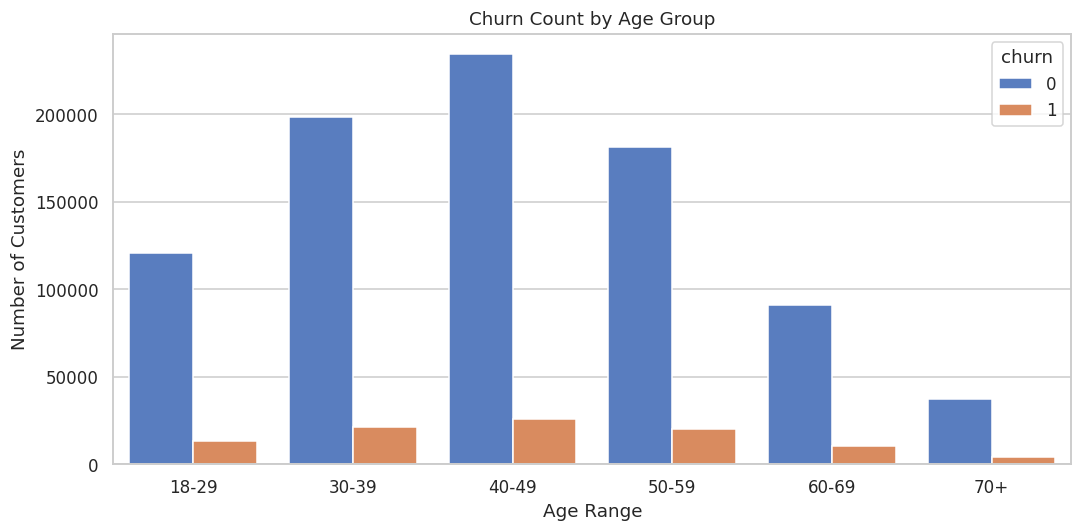

In [24]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 70, 100],
    labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='age_group', hue='churn', ax=ax)
ax.set_title('Churn Count by Age Group')
ax.set_xlabel('Age Range')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### 5g. Contract Type vs Churn

**Observation:** Month-to-month contracts show the highest churn ratio.  
**Inference:** Contract type is likely one of the strongest categorical predictors. Use one-hot encoding in modelling pipelines.

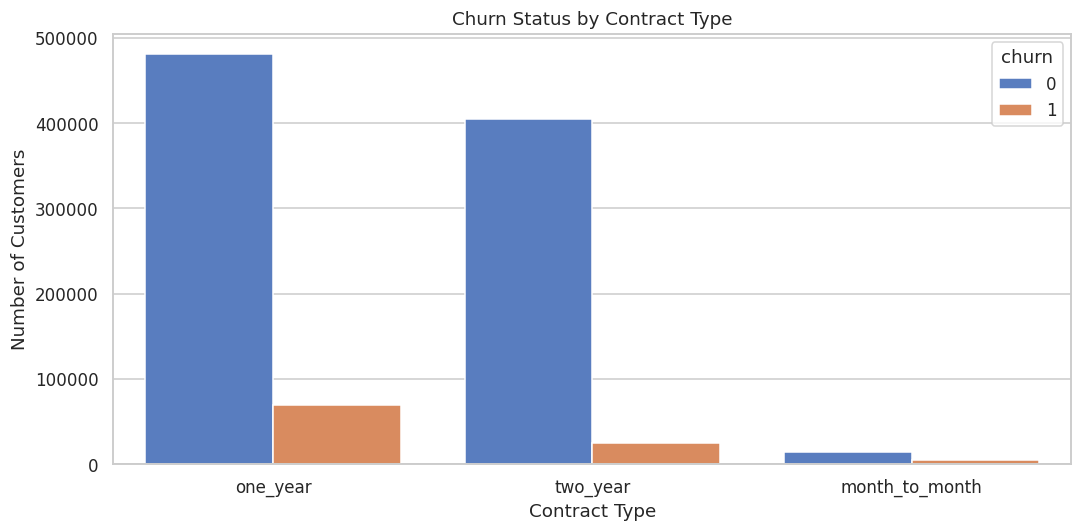

churn                   0          1
contract                            
month_to_month  73.494398  26.505602
one_year        87.346948  12.653052
two_year        94.348140   5.651860


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='contract', hue='churn', ax=ax)
ax.set_title('Churn Status by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

contract_churn_pct = df.groupby('contract')['churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn_pct)

### 5h. Monthly Charges vs Churn

**Observation:** Churned and retained customers have nearly identical monthly charge distributions.  
**Inference:** Monthly charges alone are a weak predictor; churn is likely driven by other factors such as service quality or tenure.

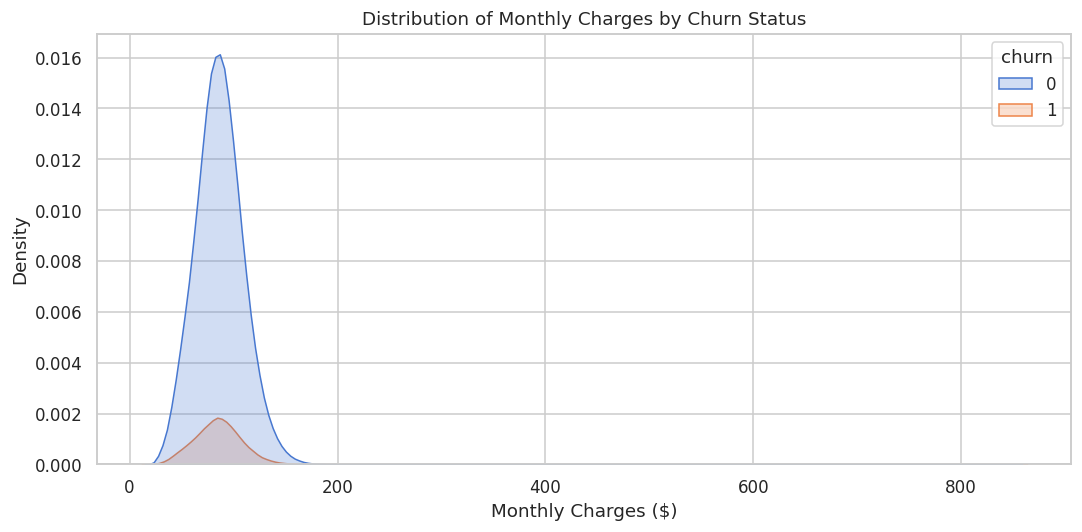

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='monthlycharges', hue='churn', fill=True, ax=ax)
ax.set_title('Distribution of Monthly Charges by Churn Status')
ax.set_xlabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

### 5i. Tenure vs Churn

**Observation:** Churn is heavily concentrated in the first 1–5 months. After 24 months the probability of churning drops sharply.  
**Inference:** Consider creating a binned tenure feature (e.g., `< 6 months`, `6–24 months`, `> 24 months`).  
**Leakage warning:** Be cautious combining `tenure` and `contract` as features — two-year contracts artificially inflate tenure for retained customers.

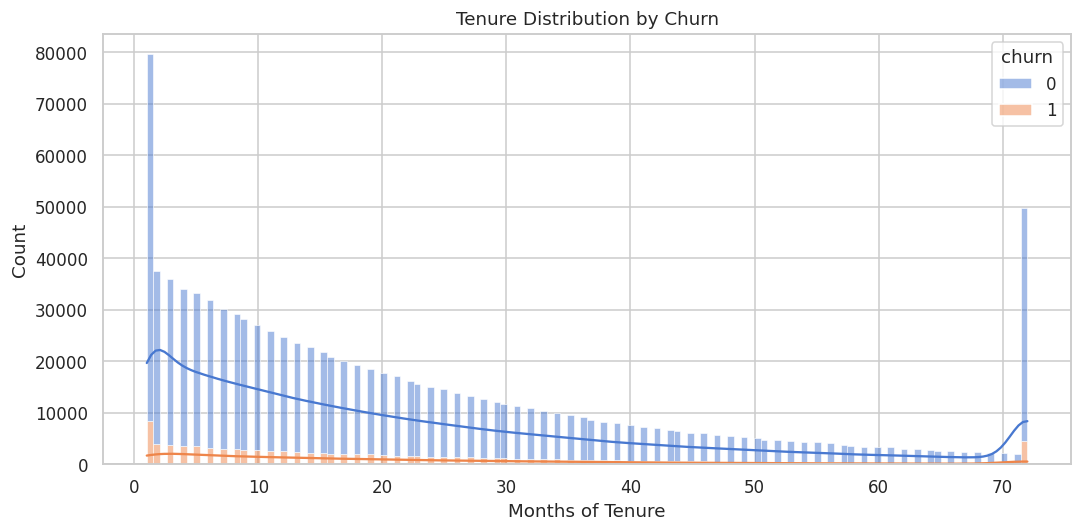

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='churn', multiple='stack', kde=True, ax=ax)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Months of Tenure')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis
### 6a. Numeric — Pearson Correlation

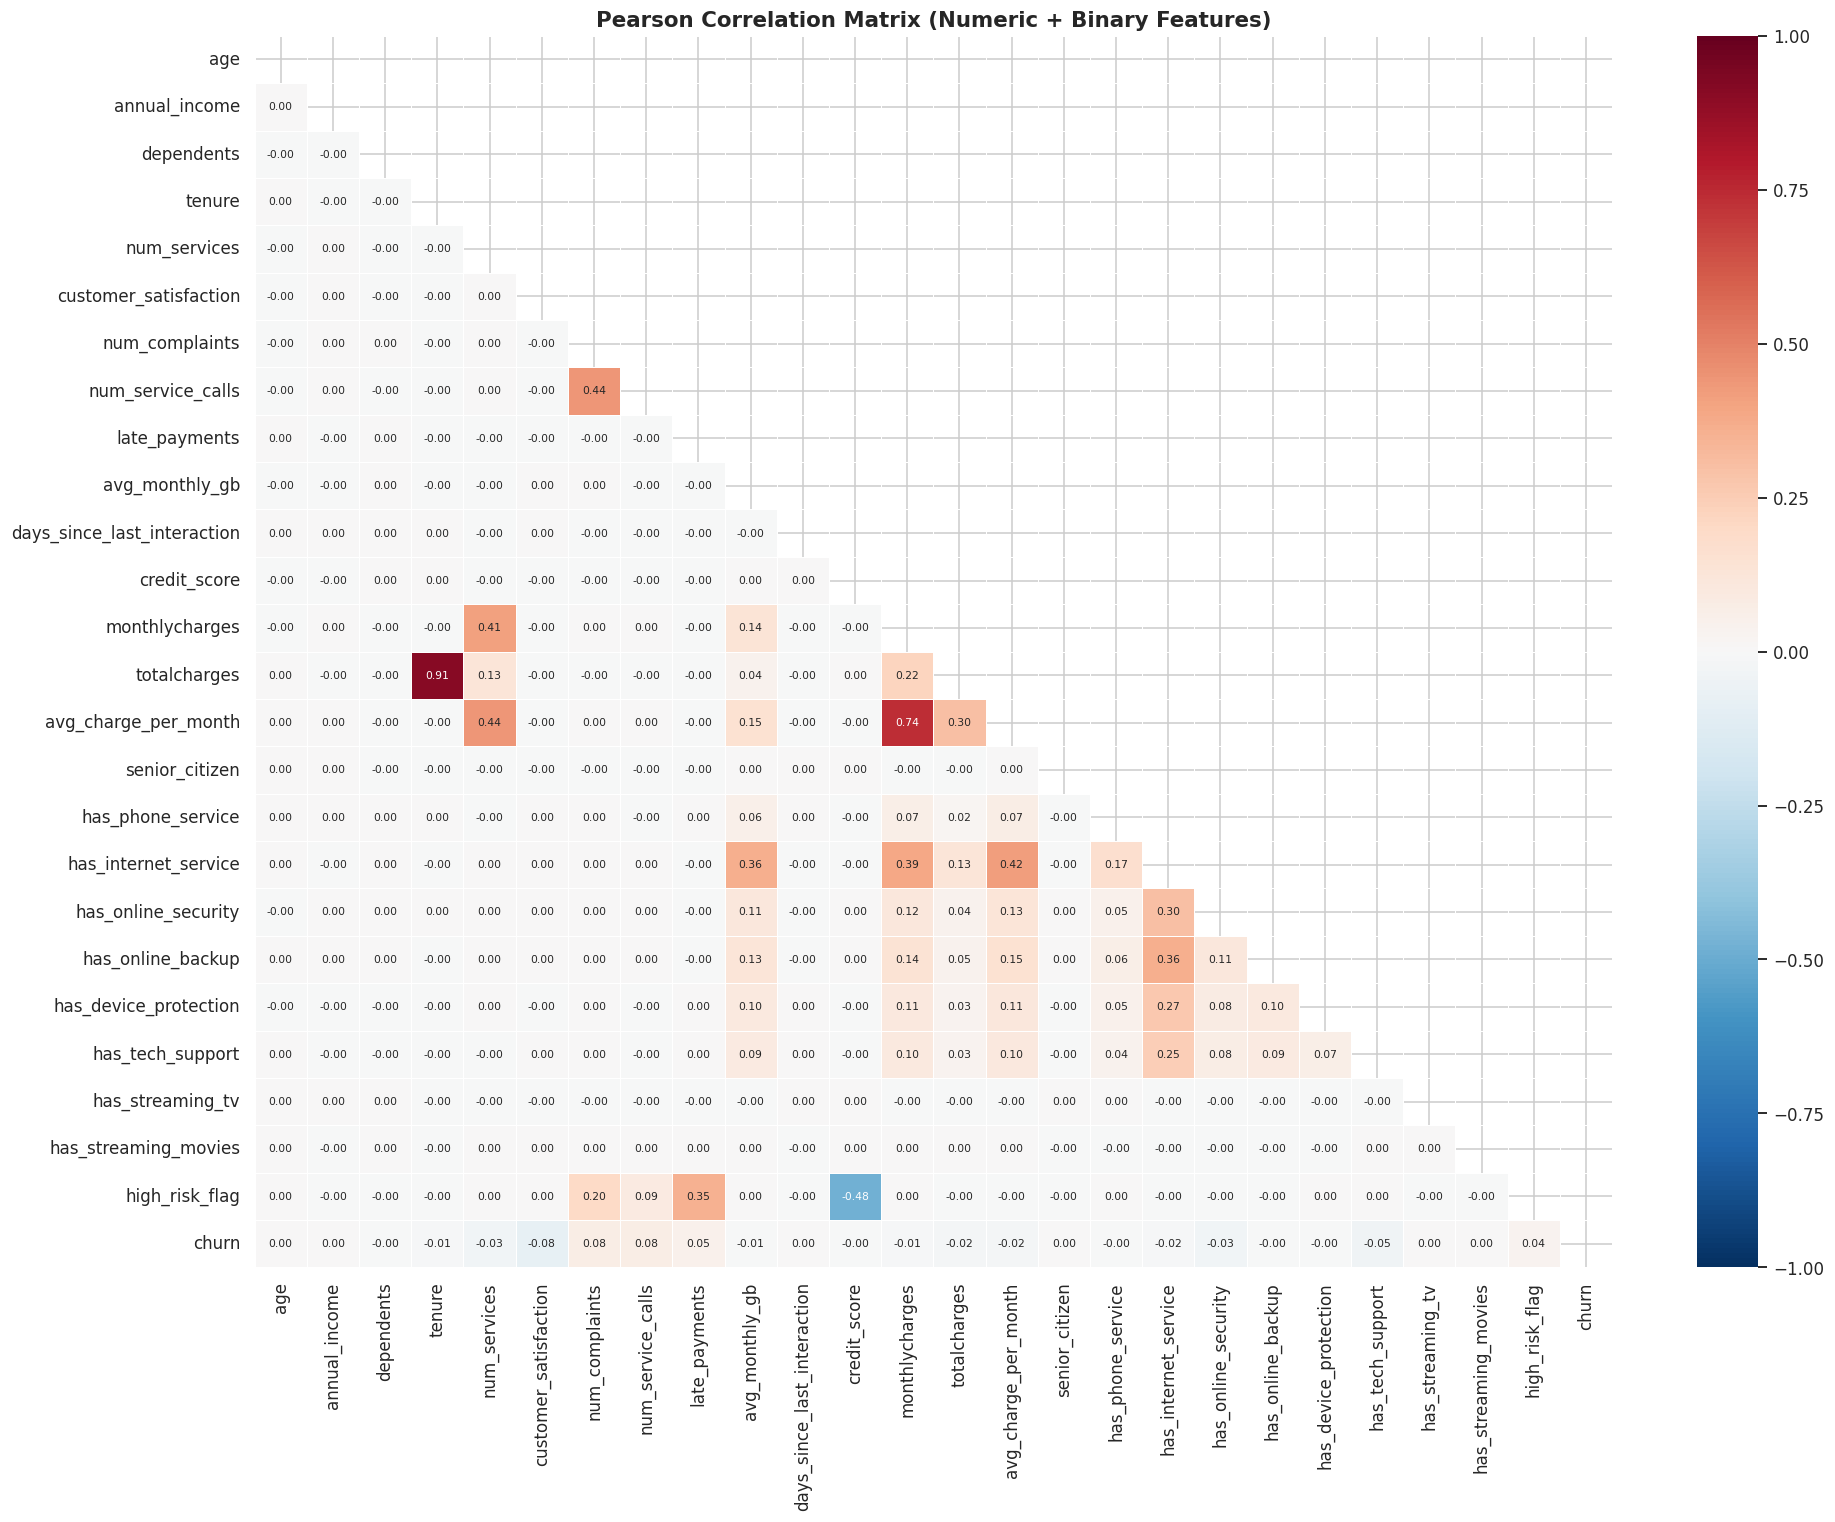


Top 10 correlations with churn:
customer_satisfaction    0.083820
num_complaints           0.077962
num_service_calls        0.077284
late_payments            0.047705
has_tech_support         0.045477
high_risk_flag           0.036369
has_online_security      0.034106
num_services             0.033378
totalcharges             0.016501
avg_charge_per_month     0.015864


In [28]:
num_corr_cols = NUM_COLS + BINARY_COLS + ['churn']
corr_matrix = df[num_corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Pearson Correlation Matrix (Numeric + Binary Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 correlations with churn:')
print(corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False).head(10).to_string())

### 6b. Categorical — Cramér's V

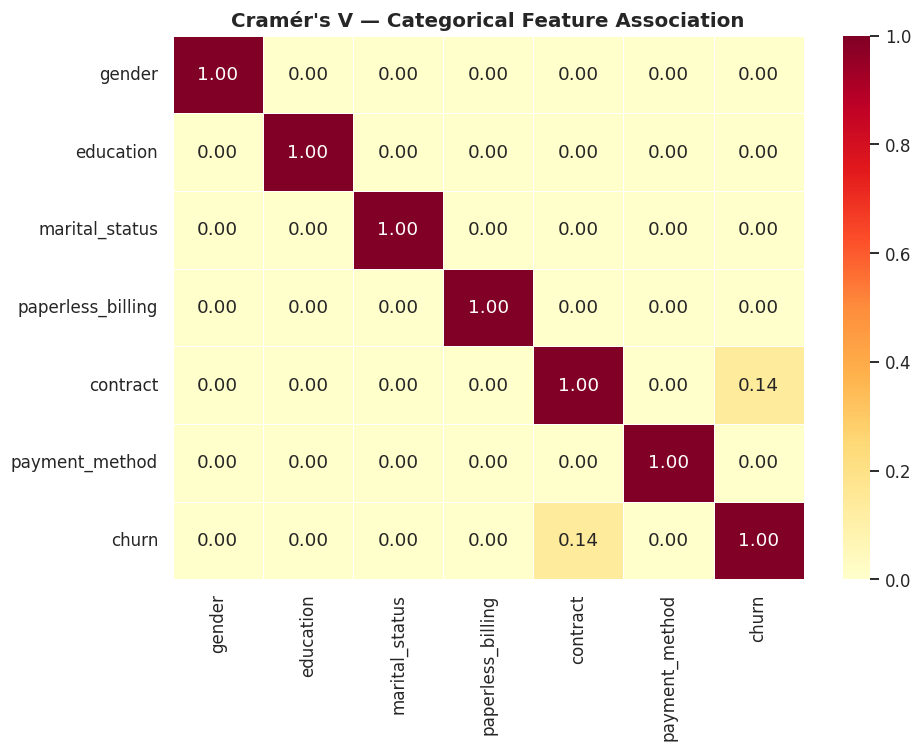


Cramér's V with churn:
contract             0.139670
marital_status       0.002220
education            0.001578
paperless_billing    0.001312
payment_method       0.000836
gender               0.000492


In [29]:
def cramers_v(x, y):
    """Cramér's V statistic for categorical-categorical association."""
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0


cat_corr_cols = CAT_COLS + ['churn']
df_cat = df[cat_corr_cols].astype(str)

cramers_matrix = pd.DataFrame(index=cat_corr_cols, columns=cat_corr_cols, dtype=float)
for col1 in cat_corr_cols:
    for col2 in cat_corr_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cramers_matrix.astype(float), annot=True, fmt='.2f',
    cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("Cramér's V — Categorical Feature Association", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCramér's V with churn:")
print(cramers_matrix['churn'].drop('churn').sort_values(ascending=False).to_string())

### 6c. Mixed — All Features (Categoricals Label-Encoded)

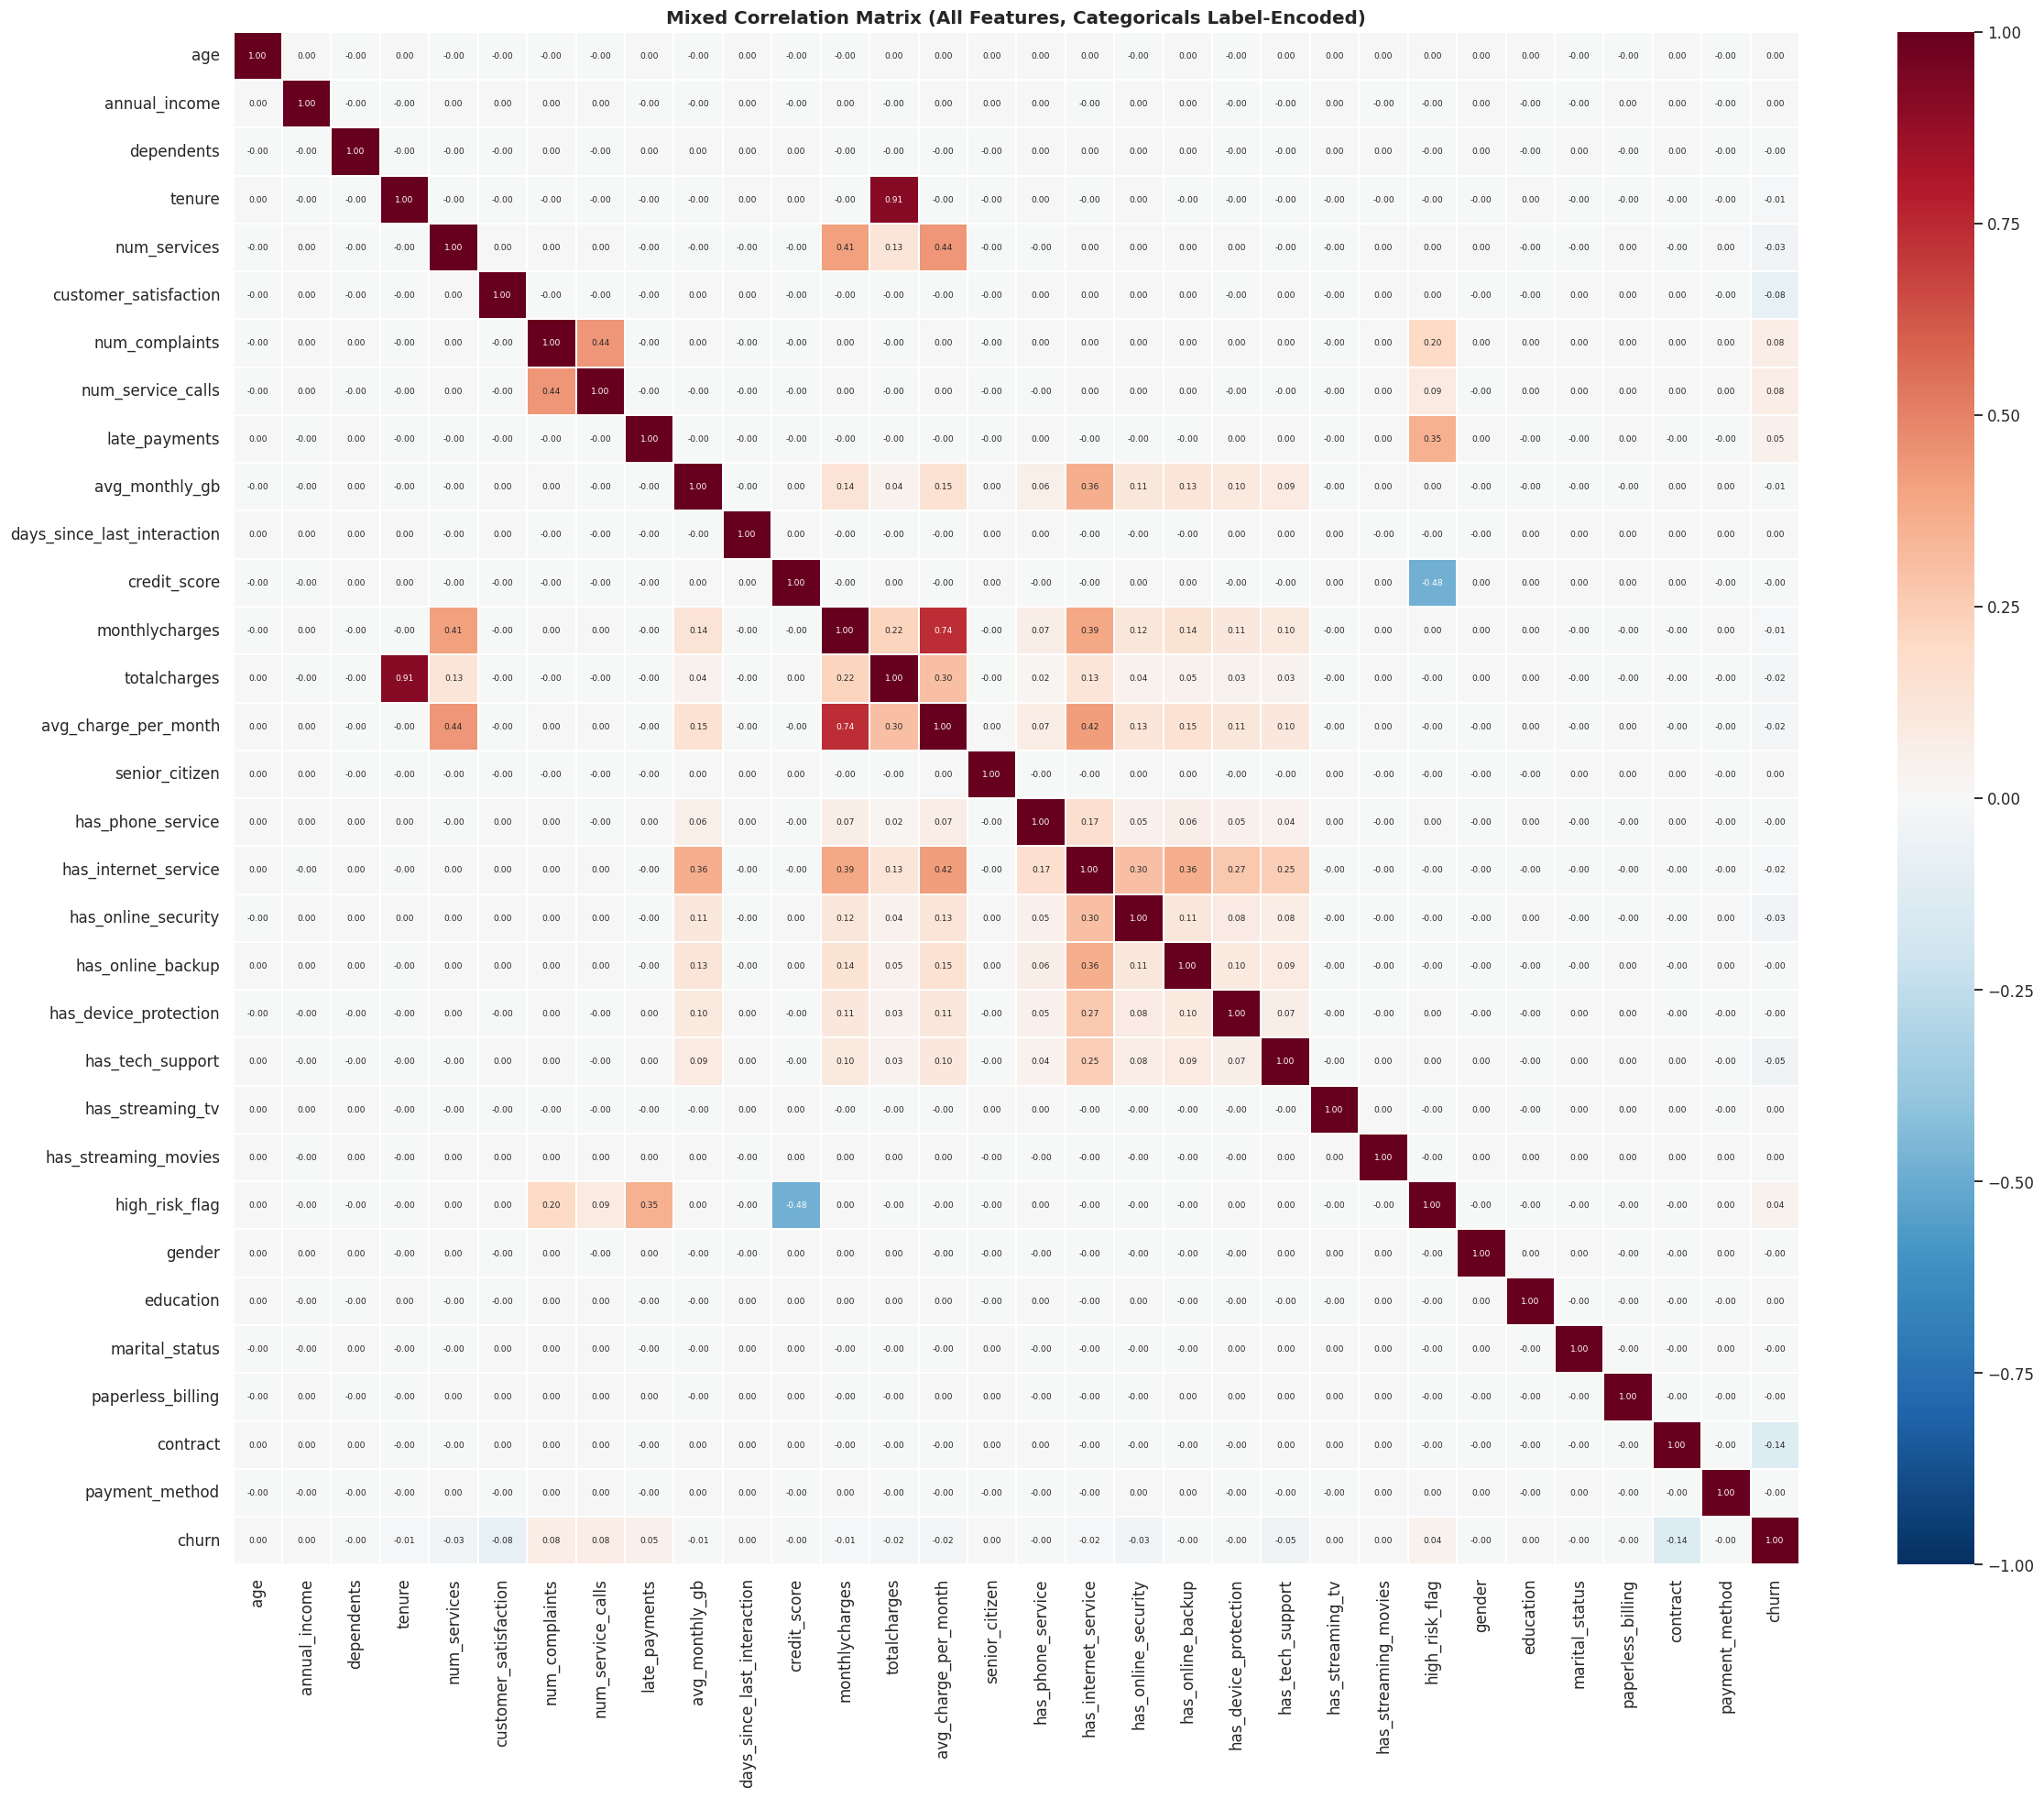


Top 15 correlations with churn (all features):
contract                 0.136480
customer_satisfaction    0.083820
num_complaints           0.077962
num_service_calls        0.077284
late_payments            0.047705
has_tech_support         0.045477
high_risk_flag           0.036369
has_online_security      0.034106
num_services             0.033378
totalcharges             0.016501
avg_charge_per_month     0.015864
has_internet_service     0.015261
monthlycharges           0.013849
tenure                   0.012709
avg_monthly_gb           0.006065


In [30]:
df_encoded = df[NUM_COLS + BINARY_COLS + CAT_COLS + ['churn']].copy()

le = LabelEncoder()
for col in CAT_COLS:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

mixed_corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    mixed_corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 6}
)
ax.set_title('Mixed Correlation Matrix (All Features, Categoricals Label-Encoded)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 15 correlations with churn (all features):')
print(mixed_corr['churn'].drop('churn').abs().sort_values(ascending=False).head(15).to_string())

## 7. Per-Dimension Feature Relevance

For each dimension we compute:
- **Point-biserial correlation** (continuous features vs binary churn label)
- **Cramér's V** (categorical features vs churn)
- **Mutual Information** (sample of 100k rows for speed)

A shared helper function keeps the code DRY across dimensions.

In [31]:
def dimension_relevance(df, continuous_features, categorical_features,
                        binary_features=None, sample_n=100_000):
    """
    Returns (stats_df, mi_df) — statistical association table and
    mutual-information ranking for the given feature lists.
    """
    binary_features = binary_features or []
    results = []

    for col in continuous_features:
        valid = df[[col, 'churn']].dropna()
        corr, p_val = pointbiserialr(valid[col], valid['churn'])
        results.append({'Feature': col, 'Type': 'Numeric',
                        'Metric_Value': corr, 'P_Value': p_val})

    for col in categorical_features:
        ct = pd.crosstab(df[col], df['churn'])
        chi2, p_val, _, _ = chi2_contingency(ct)
        n = ct.sum().sum()
        cv = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        results.append({'Feature': col, 'Type': 'Categorical',
                        'Metric_Value': cv, 'P_Value': p_val})

    all_features = continuous_features + categorical_features + binary_features
    df_sample = df.sample(min(sample_n, len(df)), random_state=42)
    X = pd.get_dummies(df_sample[all_features], drop_first=True)
    y = df_sample['churn']
    mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
    mi_df = (pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores})
               .sort_values('MI_Score', ascending=False))

    stats_df = pd.DataFrame(results).sort_values('Metric_Value', ascending=False)
    return stats_df, mi_df

### 7a. Customer Dimension

In [32]:
stats, mi = dimension_relevance(
    df,
    continuous_features=['dependents'],
    categorical_features=['tenure_segment', 'age_group', 'income_group',
                          'education', 'marital_status'],
)
print('--- Statistical Association (Customer Dimension) ---')
print(stats.to_string(index=False))
print('\n--- Mutual Information (top 10) ---')
print(mi.head(10).to_string(index=False))

--- Statistical Association (Customer Dimension) ---
       Feature        Type  Metric_Value      P_Value
tenure_segment Categorical      0.012245 2.703973e-32
     age_group Categorical      0.003237 7.406237e-02
marital_status Categorical      0.002220 1.770926e-01
  income_group Categorical      0.001628 6.180220e-01
     education Categorical      0.001578 6.466886e-01
    dependents     Numeric     -0.000145 8.844433e-01

--- Mutual Information (top 10) ---
          Feature_Encoded  MI_Score
   marital_status_married  0.010794
    tenure_segment_Stable  0.008391
    marital_status_single  0.005869
income_group_Middle-lower  0.004750
          age_group_40-49  0.004555
               dependents  0.004512
     tenure_segment_Loyal  0.004215
          age_group_30-39  0.003624
        education_college  0.002354
    education_high_school  0.002040


### 7b. Account Dimension

In [33]:
stats, mi = dimension_relevance(
    df,
    continuous_features=['tenure'],
    categorical_features=['contract', 'payment_method', 'paperless_billing'],
)
print('--- Statistical Association (Account Dimension) ---')
print(stats.to_string(index=False))
print('\n--- Mutual Information (top 10) ---')
print(mi.head(10).to_string(index=False))

--- Statistical Association (Account Dimension) ---
          Feature        Type  Metric_Value      P_Value
         contract Categorical      0.139670 0.000000e+00
paperless_billing Categorical      0.001312 1.896012e-01
   payment_method Categorical      0.000836 8.733100e-01
           tenure     Numeric     -0.012709 5.257930e-37

--- Mutual Information (top 10) ---
                Feature_Encoded  MI_Score
              contract_two_year  0.020253
              contract_one_year  0.018987
          paperless_billing_Yes  0.017212
     payment_method_credit_card  0.006801
payment_method_electronic_check  0.004418
    payment_method_mailed_check  0.002297
                         tenure  0.000122


### 7c. Service Dimension

In [34]:
stats, mi = dimension_relevance(
    df,
    continuous_features=[],
    categorical_features=[
        'num_services', 'has_phone_service', 'has_internet_service',
        'has_online_security', 'has_online_backup', 'has_device_protection',
        'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
    ],
)
print('--- Statistical Association (Service Dimension) ---')
print(stats.to_string(index=False))
print('\n--- Mutual Information (top 10) ---')
print(mi.head(10).to_string(index=False))

--- Statistical Association (Service Dimension) ---
              Feature        Type  Metric_Value       P_Value
     has_tech_support Categorical      0.045474  0.000000e+00
  has_online_security Categorical      0.034103 6.731298e-255
         num_services Categorical      0.033433 1.920736e-239
 has_internet_service Categorical      0.015257  1.484207e-52
    has_online_backup Categorical      0.004916  8.829956e-07
has_device_protection Categorical      0.004905  9.364946e-07
    has_phone_service Categorical      0.002270  2.323550e-02
 has_streaming_movies Categorical      0.001911  5.595205e-02
     has_streaming_tv Categorical      0.000692  4.891973e-01

--- Mutual Information (top 10) ---
      Feature_Encoded  MI_Score
 has_internet_service  0.016146
    has_phone_service  0.015980
     has_tech_support  0.014969
     has_streaming_tv  0.014397
 has_streaming_movies  0.012602
    has_online_backup  0.009693
  has_online_security  0.006494
has_device_protection  0.003741
   

### 7d. Behaviour Dimension

In [35]:
stats, mi = dimension_relevance(
    df,
    continuous_features=[
        'customer_satisfaction', 'num_complaints', 'num_service_calls',
        'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score',
    ],
    categorical_features=['high_risk_flag'],
)
print('--- Statistical Association (Behaviour Dimension) ---')
print(stats.to_string(index=False))
print('\n--- Mutual Information (top 10) ---')
print(mi.head(10).to_string(index=False))

--- Statistical Association (Behaviour Dimension) ---
                    Feature        Type  Metric_Value       P_Value
             num_complaints     Numeric      0.077962  0.000000e+00
          num_service_calls     Numeric      0.077284  0.000000e+00
              late_payments     Numeric      0.047705  0.000000e+00
             high_risk_flag Categorical      0.036365 1.531227e-289
days_since_last_interaction     Numeric      0.000391  6.955420e-01
               credit_score     Numeric     -0.000370  7.115182e-01
             avg_monthly_gb     Numeric     -0.006065  1.316983e-09
      customer_satisfaction     Numeric     -0.083820  0.000000e+00

--- Mutual Information (top 10) ---
            Feature_Encoded  MI_Score
             num_complaints  0.006392
          num_service_calls  0.006379
      customer_satisfaction  0.005779
             high_risk_flag  0.003711
              late_payments  0.002236
             avg_monthly_gb  0.000000
days_since_last_interaction  0.

### 7e. Fact Dimension

In [36]:
stats, mi = dimension_relevance(
    df,
    continuous_features=['monthlycharges', 'totalcharges', 'avg_charge_per_month'],
    categorical_features=[],
)
print('--- Statistical Association (Fact Dimension) ---')
print(stats.to_string(index=False))
print('\n--- Mutual Information (top 10) ---')
print(mi.head(10).to_string(index=False))

--- Statistical Association (Fact Dimension) ---
             Feature    Type  Metric_Value      P_Value
      monthlycharges Numeric     -0.013849 1.286515e-43
avg_charge_per_month Numeric     -0.015864 1.102169e-56
        totalcharges Numeric     -0.016501 3.531960e-61

--- Mutual Information (top 10) ---
     Feature_Encoded  MI_Score
        totalcharges  0.000614
avg_charge_per_month  0.000407
      monthlycharges  0.000000


## 8. Collinearity Investigation (Training Features)

In [37]:
labels_true = df_train['churn'].copy()
df_features = df_train.drop(columns=['churn', 'customer_id'])

categorical_cols = ['contract', 'age_group', 'tenure_segment']
df_enc = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

print('Encoded training columns:')
print(df_enc.columns.tolist())

Encoded training columns:
['annual_income', 'has_phone_service', 'has_internet_service', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'high_risk_flag', 'is_auto_pay', 'contract_one_year', 'contract_two_year', 'age_group_18-29', 'age_group_30-39', 'age_group_40-49', 'age_group_50-59', 'age_group_60-69', 'age_group_70+', 'tenure_segment_Loyal', 'tenure_segment_Stable', 'tenure_segment_Veteran']


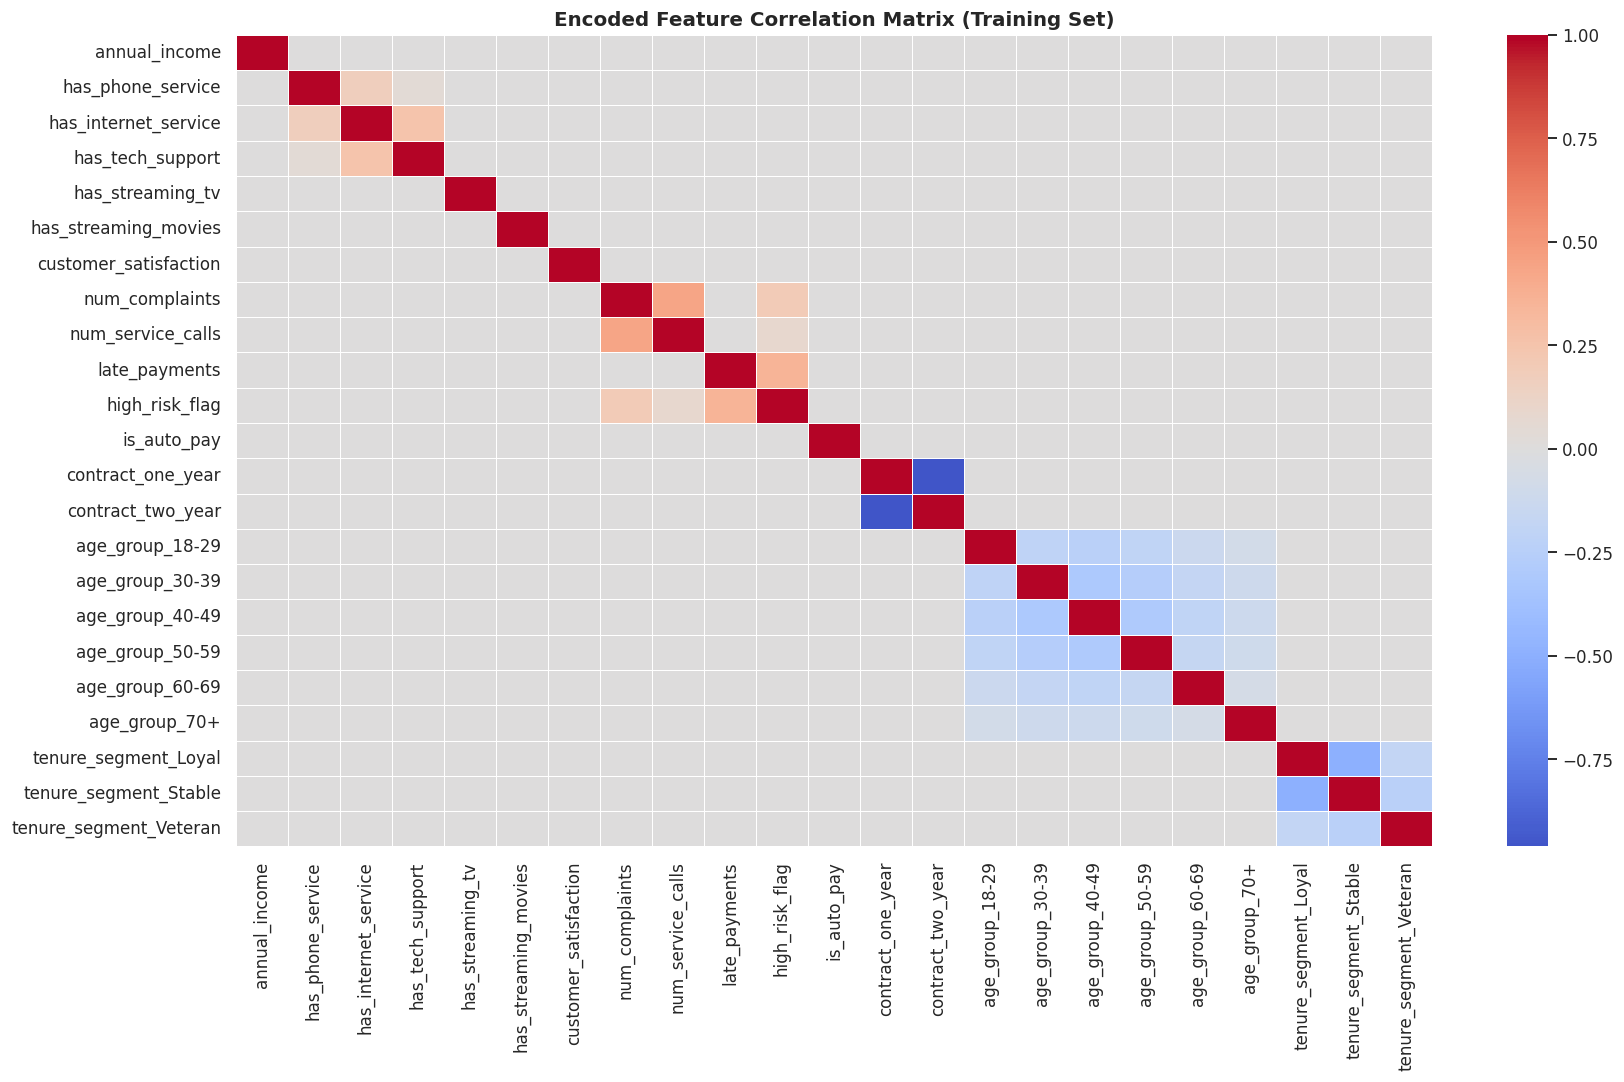


Highly correlated feature pairs (|r| > 0.7):
        Feature A         Feature B  Correlation
contract_one_year contract_two_year    -0.960229


In [38]:
corr_matrix_train = df_enc.corr()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    corr_matrix_train,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Encoded Feature Correlation Matrix (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Correlation'})
         .query('Correlation.abs() > 0.7')
         .sort_values('Correlation', key=abs, ascending=False)
)
print('\nHighly correlated feature pairs (|r| > 0.7):')
print(high_corr.to_string(index=False))